## Opis projektu

Celem naszego projektu jest zastosowanie sztucznych sieci neuronowych w celu prognozy cen samochodów używanych. Do analizy i predykcji cen aut zostaną uwzględnione kluczowe parametry, takie jak rok produkcji, typ paliwa, liczba cylindrów, przebieg, rodzaj skrzyni biegów, stan pojazdu. 
W ramach projektu przeprowadzona zostanie również dogłębna analiza wpływu różnych parametrów sztucznych sieci neuronowych na efektywność oraz precyzję przewidywań cenowych.

## Biblioteki 

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from random import seed
from random import random
from math import exp
import numpy as np
from perceptron import *
from itertools import product
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import json
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
import warnings 
warnings.filterwarnings("ignore")

## Przygotowanie danych

In [6]:
dane_klas = pd.read_csv('dane/vehicles.csv')

Wybrane zmienne:
- price - cena samochodu
- year - rok produkcji
- fuel - typ paliwa
- cylinders - liczba cylindrów
- odometer - liczba przejechanych km
- transmission - rodzaj skrzyni biegów
- condition - stan pojazdu

### Statystyki opisowe

In [7]:
def stats(df=dane_klas, cols=None):
    if cols is None:
        cols = ['price', 'year', 'fuel', 'cylinders', 'odometer', 'transmission', 'condition']
    selected = df[cols]
    summary = pd.DataFrame({
        'dtype': selected.dtypes.astype(str),
        'n_non_null': selected.notna().sum(),
        'n_null': selected.isna().sum(),
        'pct_null': (selected.isna().mean() * 100).round(2)
    })
    print(summary)
    return selected, summary

dane_klas, cols_summary = stats()

                dtype  n_non_null  n_null  pct_null
price           int64      426880       0      0.00
year          float64      425675    1205      0.28
fuel           object      423867    3013      0.71
cylinders      object      249202  177678     41.62
odometer      float64      422480    4400      1.03
transmission   object      424324    2556      0.60
condition      object      252776  174104     40.79


Dane wskazują, że większość kluczowych cech (rok, paliwo, przebieg, skrzynia biegów, stan) ma niewielki odsetek braków, z wyjątkiem liczby cylindrów i stanu pojazdu (ok. 40% braków), co wymaga uzupełnienia lub odpowiedniego przetworzenia.

### Usuwanie braków

Ze względu na dużą liczbę zmiennych oraz występowanie braków danych w niektórych kolumnach, zdecydowano się na oczyszczenie zbioru danych. W pierwszej kolejności zidentyfikowano kolumny zawierające wartości puste i usunięto rekordy z brakami w tych polach. Następnie odfiltrowano obserwacje z niepoprawnymi wartościami — usunięto rekordy, w których cena wynosiła 0 oraz pojazdy wyprodukowane przed 1990 rokiem. Dodatkowo wykluczono przypadki, w których przebieg był równy 0, o ile stan pojazdu nie wskazywał na nowy (warunek condition == 2). Dzięki tym krokom uzyskano bardziej spójny i wiarygodny zbiór danych do dalszej analizy oraz modelowania cen samochodów.

In [8]:
cols_with_nulls = cols_summary[cols_summary['n_null'] > 0].index.tolist()
dane_klas = dane_klas.dropna(subset=cols_with_nulls).reset_index(drop=True)

dane_klas = dane_klas.loc[dane_klas['price'] != 0]
dane_klas = dane_klas.loc[dane_klas['year'] > 1990]
dane_klas = dane_klas[dane_klas.apply(lambda row: row['odometer'] != 0 or row['condition'] == 2, axis=1)]
dane_klas.head()

,price,year,fuel,cylinders,odometer,transmission,condition
0,33590,2014.0,gas,8 cylinders,57923.0,other,good
1,22590,2010.0,gas,8 cylinders,71229.0,other,good
2,39590,2020.0,gas,8 cylinders,19160.0,other,good
3,30990,2017.0,gas,8 cylinders,41124.0,other,good
4,15000,2013.0,gas,6 cylinders,128000.0,automatic,excellent


### Wartości odstające 

Aby poprawić jakość danych i zmniejszyć wpływ wartości ekstremalnych na model predykcyjny, zastosowano metodę **IQR (Interquartile Range)**.  
Na podstawie kwartylu pierwszego (Q1) i trzeciego (Q3) obliczono rozstęp międzykwartylowy:

$$
IQR = Q3 - Q1
$$

Następnie usunięto obserwacje, dla których cena znajdowała się poza zakresem:

$$
[Q1 - 1.5 \times IQR,\; Q3 + 1.5 \times IQR]
$$

W efekcie wyeliminowano wartości odstające w kolumnie *price*, co pozwala na bardziej wiarygodną analizę i dokładniejsze przewidywanie cen pojazdów. To samo wykonano dla kolumny *odometer*



In [9]:
Q1 = dane_klas['price'].quantile(0.25)
Q3 = dane_klas['price'].quantile(0.75)
IQR = Q3 - Q1

dane_klas = dane_klas[(dane_klas['price'] >= Q1 - 1.5 * IQR) & (dane_klas['price'] <= Q3 + 1.5 * IQR)].reset_index(drop=True)

Q1 = dane_klas['odometer'].quantile(0.25)
Q3 = dane_klas['odometer'].quantile(0.75)
IQR = Q3 - Q1

dane_klas = dane_klas[(dane_klas['odometer'] >= Q1 - 1.5 * IQR) & (dane_klas['odometer'] <= Q3 + 1.5 * IQR)].reset_index(drop=True)

print("Rozmiar po usunięciu outlierów (IQR):", dane_klas.shape)

Rozmiar po usunięciu outlierów (IQR): (161511, 7)


###  Kodowanie zmiennych kategorycznych

W celu przygotowania danych do uczenia modelu, zidentyfikowano wszystkie kolumny o typie **kategorycznym**:

Spośród nich wybrano te, które zawierają **nie więcej niż 50 unikalnych wartości**, aby umożliwić ich efektywne zakodowanie metodą **One-Hot Encoding**:

Następnie dla tych kolumn utworzono zmienne zero-jedynkowe przy użyciu funkcji `pd.get_dummies()`, co pozwoliło na przekształcenie danych kategorycznych w formę numeryczną, wymaganą przez algorytmy uczenia maszynowego.  

Proces ten zwiększył liczbę kolumn w zbiorze danych, ale zapewnił pełną reprezentację cech kategorycznych w analizie i modelowaniu.

In [10]:
cat_cols = dane_klas.select_dtypes(include=['object', 'category']).columns.tolist()

cols_to_encode = [c for c in cat_cols if dane_klas[c].nunique(dropna=True) <= 50]
print(f"Znalezione kolumny kategoryczne: {cat_cols}")
print(f"Kolumny, które będą zakodowane (<=50 unikalnych): {cols_to_encode}")

dane_klas = pd.get_dummies(dane_klas, columns=cols_to_encode, dummy_na=False, drop_first=False)

print("Rozmiar przed:", dane_klas.shape, "po:", dane_klas.shape)
dane_klas.head()

bool_cols = dane_klas.select_dtypes(include='bool').columns
dane_klas[bool_cols] = dane_klas[bool_cols].astype(int)

Znalezione kolumny kategoryczne: ['fuel', 'cylinders', 'transmission', 'condition']
Kolumny, które będą zakodowane (<=50 unikalnych): ['fuel', 'cylinders', 'transmission', 'condition']
Rozmiar przed: (161511, 25) po: (161511, 25)


###  Wizualizacja rozkładów i zależności cen samochodów

Aby lepiej zrozumieć charakterystykę danych oraz zależności między zmiennymi, przeprowadzono analizę eksploracyjną z wykorzystaniem bibliotek **Seaborn** i **Matplotlib**.

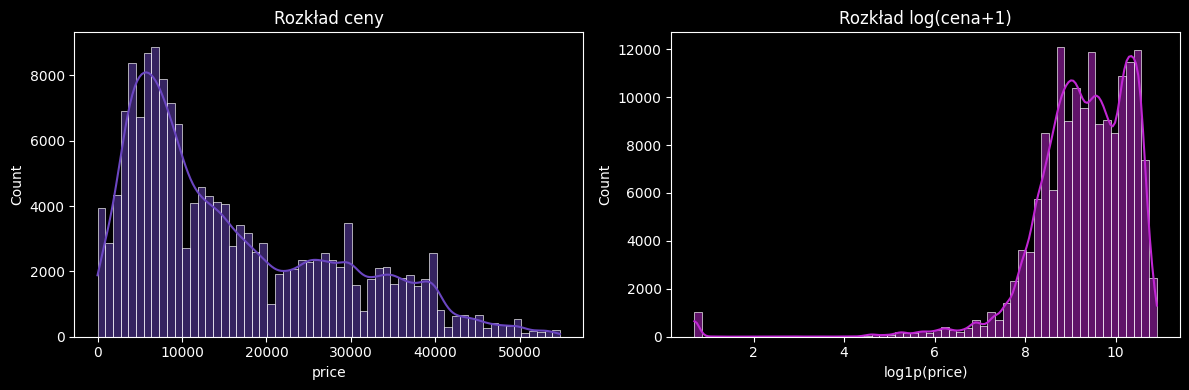

In [11]:

COLORS = {
    'primary': '#6B46C1',
    'secondary': '#9333EA',
    'accent': '#C026D3',
    'light': '#A78BFA',
    'pink': '#EC4899',
    'dark': '#5B21B6',
    'cyan': '#06B6D4'
}

# Gradient kolorów
GRADIENT = ['#5B21B6', '#6B46C1', '#9333EA', '#A78BFA', '#C026D3', '#EC4899']

# Ustawienie stylu
plt.style.use('dark_background')
sns.set_palette(GRADIENT)


data_plots = dane_klas.copy()
trans_cols = [c for c in dane_klas.columns if c.startswith('transmission_')]
data_plots['transmission_cat'] = data_plots[trans_cols].idxmax(axis=1).str.replace('transmission_', '')


cond_cols = [c for c in dane_klas.columns if c.startswith('condition_')]
data_plots['condition_cat'] = data_plots[cond_cols].idxmax(axis=1).str.replace('condition_', '')

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(data_plots['price'], bins=60, kde=True, color=COLORS['primary'])
plt.xlabel('price')
plt.title('Rozkład ceny')

plt.subplot(1,2,2)
sns.histplot(np.log1p(data_plots['price']), bins=60, kde=True, color=COLORS['accent'])
plt.xlabel('log1p(price)')
plt.title('Rozkład log(cena+1)')
plt.tight_layout()
plt.show()


1. **Rozkład cen (`price`)**  
   Utworzono histogram ceny oraz jej przekształcenia logarytmicznego `log1p(price)`.  
   Transformacja logarytmiczna pozwala zmniejszyć wpływ wartości skrajnych i uwidocznić strukturę danych, która  ma rozkład prawoskośny. Większość aut kosztuje poniżej 20 000, a tylko nieliczne mają znacznie wyższe ceny.

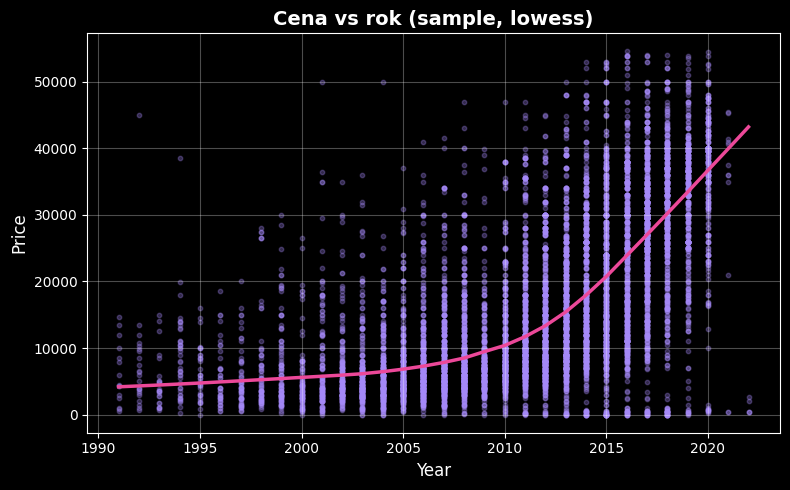

In [12]:
sample = data_plots.sample(n=min(len(data_plots), 10000), random_state=42)
plt.figure(figsize=(8,5))
sns.regplot(data=sample, x='year', y='price',
            scatter_kws={'s':10, 'alpha':0.3, 'color': COLORS['light']}, 
            lowess=True, 
            line_kws={'color': COLORS['pink'], 'linewidth': 2.5})
plt.title('Cena vs rok (sample, lowess)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

2. **Zależność ceny od roku produkcji**  
   Wykorzystano wykres regresji (z dopasowaniem *lowess*), który pokazuje, że **nowsze auta mają generalnie wyższe ceny**, co jest zgodne z oczekiwaniami rynkowymi. Zrzywa lowess potwierdza trend wzrostowy, szczególnie po 2010 roku. 

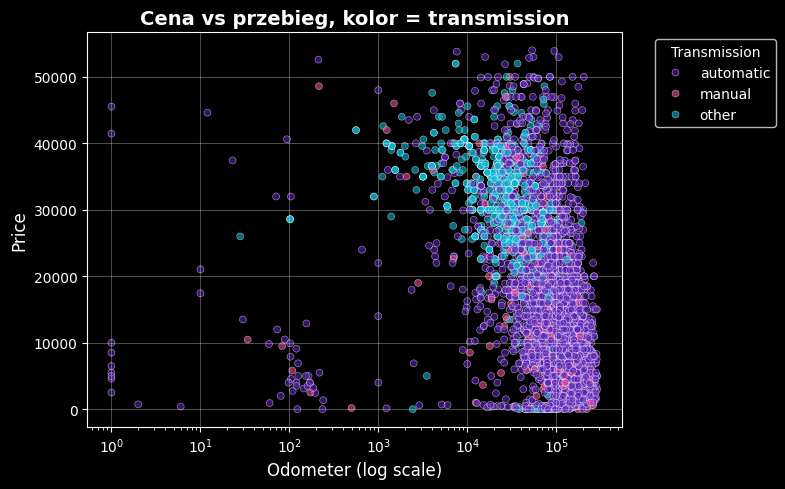

In [13]:
# 2. Scatterplot - Cena vs przebieg
sample2 = data_plots.sample(n=min(len(data_plots), 5000), random_state=42)
plt.figure(figsize=(8,5))

# Bardziej kontrastowe kolory dla lepszego rozróżnienia
CONTRAST_COLORS = [COLORS['dark'], COLORS['pink'], COLORS['cyan']]

sns.scatterplot(data=sample2, x='odometer', y='price', hue='transmission_cat', 
                alpha=0.6, s=25, palette=CONTRAST_COLORS)
plt.xscale('log')
plt.xlabel('Odometer (log scale)', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.title('Cena vs przebieg, kolor = transmission', fontsize=14, fontweight='bold')
plt.legend(title='Transmission', bbox_to_anchor=(1.05, 1), loc='upper left', 
           framealpha=0.9, fancybox=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


3. **Cena a przebieg (`odometer`) z rozróżnieniem skrzyni biegów**  
   Skala logarytmiczna dla przebiegu ułatwia wizualizację szerokiego zakresu wartości. Widoczna jest **ujemna korelacja** — im większy przebieg, tym niższa cena. Dodatkowo można zauważyć, że samochody z automatyczną skrzynią biegów częściej osiągają wyższe ceny niż manualne. 

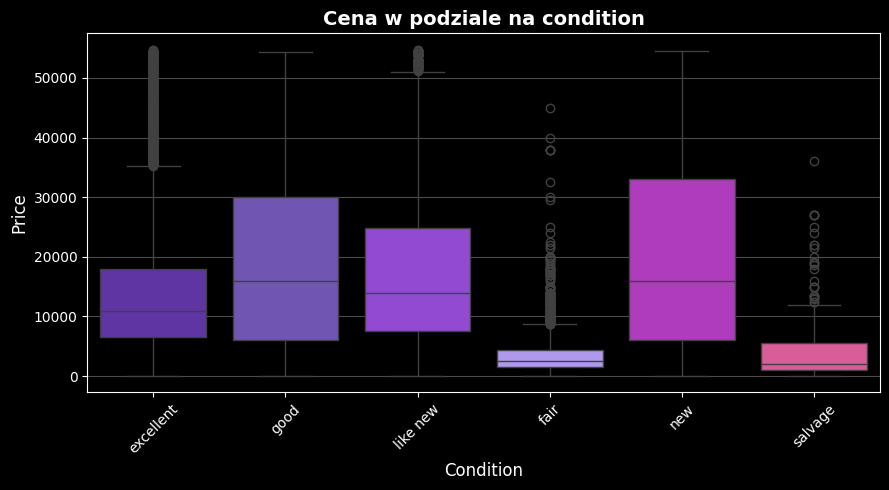

In [14]:
plt.figure(figsize=(9,5))
order = data_plots['condition_cat'].value_counts().index
sns.boxplot(data=data_plots, x='condition_cat', y='price', order=order, palette=GRADIENT)
plt.xticks(rotation=45)
plt.title('Cena w podziale na condition', fontsize=14, fontweight='bold')
plt.xlabel('Condition', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


4. **Cena w zależności od stanu pojazdu (`condition_cat`)**  
   Za pomocą wykresu pudełkowego przedstawiono różnice cen między grupami opisującymi stan techniczny auta.  
   **Lepszy stan pojazdu wiąże się z wyższą medianą ceny**, co potwierdza przewidywaną zależność.


---

### Ograniczenie wielkości zbioru danych

Ze względu na bardzo dużą liczbę obserwacji w oryginalnym zbiorze danych trenowanie modeli  mogłoby znacząco wydłużyć czas obliczeń oraz zwiększyć zapotrzebowanie na pamięć operacyjną.

Aby usprawnić proces analizy i umożliwić szybkie testowanie modeli, zbiór został **losowo ograniczony do 80 000 obserwacji**. Wyboru dokonano metodą losowego próbkowania:

* zapewnia to reprezentatywny przekrój danych,
* minimalizuje ryzyko systematycznych zniekształceń,
* pozwala zachować strukturę i rozkład cech zbliżony do pełnego zbioru.


#### Konsekwencje statystyczne ograniczenia zbioru

Ograniczenie liczby danych przynosi zarówno korzyści, jak i potencjalne efekty uboczne.

##### **Korzyści**

* znacznie szybsze przetwarzanie danych oraz trenowanie modeli,
* mniejsze zużycie pamięci RAM,
* możliwość częstszego i szybszego eksperymentowania z różnymi konfiguracjami modeli.

##### **Potencjalne skutki**

* niewielka utrata informacji, szczególnie jeśli w pełnych danych występują rzadkie przypadki,
* minimalne różnice w estymacji parametrów modeli w stosunku do uczenia na pełnym zbiorze,
* możliwe delikatne zwiększenie wariancji predykcji przy niektórych modelach.

---

### Dodanie zmiennej „age” i przygotowanie danych numerycznych

Następnie dodano nową zmienną **„age”**, obliczoną jako różnica między rokiem 2022 a rokiem produkcji pojazdu. Pozwala ona w bardziej bezpośredni sposób uchwycić wpływ wieku auta na jego cenę, co jest kluczową informacją w modelowaniu wartości pojazdów.

Aby zapewnić porównywalność między zmiennymi oraz zwiększyć efektywność procesu uczenia modeli, przeprowadzono **standaryzację** zmiennych numerycznych (*price*, *odometer*, *age*) z wykorzystaniem metody **StandardScaler**. Operacja ta skaluje zmienne tak, aby miały średnią 0 i odchylenie standardowe 1, dzięki czemu modele są mniej podatne na dominację jednej cechy nad innymi.

Kolumna **year** została usunięta jako redundantna, ponieważ jej informacja została całkowicie odwzorowana w zmiennej *age*.

---


In [15]:
dane_klas = dane_klas.sample(n=80000, random_state=42).reset_index(drop=True)

current_year = pd.Timestamp(2022, 1, 1).year
dane_klas['age'] = current_year - dane_klas['year']

scaler = StandardScaler()
dane_klas[['price', 'odometer', 'age']] = scaler.fit_transform( dane_klas[['price', 'odometer', 'age']] )
dane_klas.drop(columns=['year'], inplace=True)


## Trenowanie sieci

In [ ]:
# np.random.seed(123)

# X_reg = dane_klas.drop(columns=['price'])
# y_reg = dane_klas['price'].values.reshape(-1, 1)


# experiment_reg = MLPExperiment(
#     task_type='regression',
#     split_variant='B',
#     n_repeats=5,
#     n_jobs=-1
# )

# results_reg = experiment_reg.run_full_experiment(X_reg, y_reg)
# experiment_reg.save_results('regression_results.json')

EKSPERYMENT MLP - REGRESSION

1. Przygotowanie danych...
  Rozmiar zbioru treningowego: (56000, 24)
  Rozmiar zbioru walidacyjnego: (12000, 24)
  Rozmiar zbioru testowego: (12000, 24)

2. Trenowanie modelu podstawowego...
  Powtórzenie 1/5
  Powtórzenie 2/5
  Powtórzenie 3/5
  Powtórzenie 4/5
  Powtórzenie 5/5

4. Random Search...
Random Search: testowanie 20 konfiguracji...
  Używam 12 procesów równoległych
  ✓ Ukończono 1/20: layers=7, neurons=16, lr=0.001972, momentum=0.431, opt=RMSProp, act=relu
  ✓ Ukończono 2/20: layers=5, neurons=80, lr=0.099403, momentum=0.384, opt=Adam, act=elu
  ✓ Ukończono 3/20: layers=7, neurons=48, lr=0.004872, momentum=0.531, opt=RMSProp, act=leaky_relu
  ✓ Ukończono 4/20: layers=6, neurons=16, lr=0.000107, momentum=0.715, opt=SGD, act=leaky_relu
  ✓ Ukończono 5/20: layers=5, neurons=48, lr=0.007992, momentum=0.628, opt=RMSProp, act=sigmoid
  ✓ Ukończono 6/20: layers=4, neurons=64, lr=0.000130, momentum=0.513, opt=Adam, act=sigmoid
  ✓ Ukończono 7/20: lay


---
## Analiza skuteczności sieci

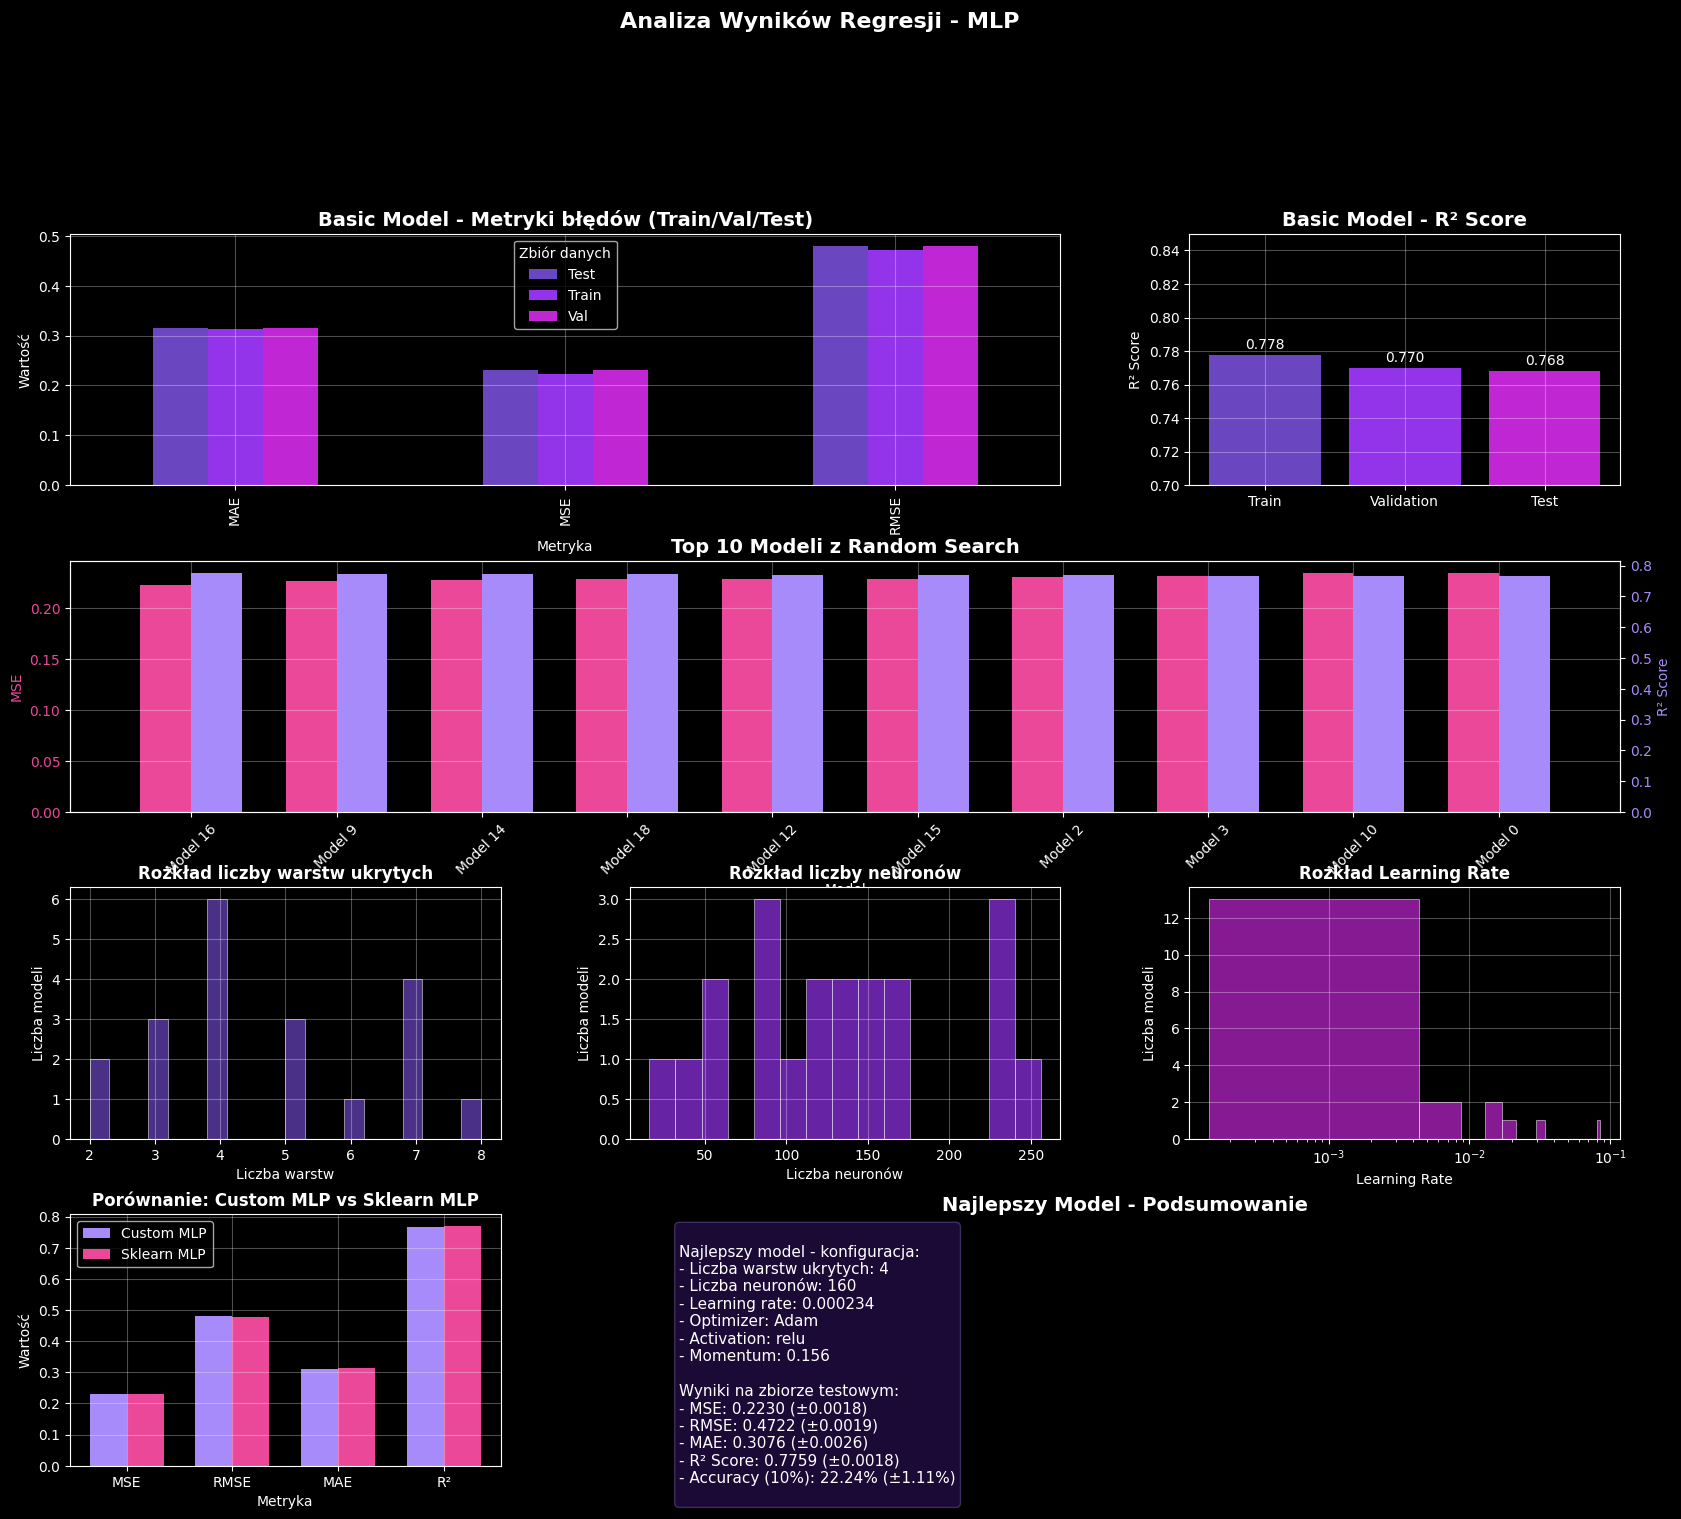

In [17]:
with open('results/regression_results_dane_vehicle.json') as f:
    reg_results = json.load(f)

# Utworzenie głównej figury z subplotami
fig = plt.figure(figsize=(20, 16))
gs = GridSpec(4, 3, figure=fig, hspace=0.3, wspace=0.3)

# 1. Porównanie metryk dla basic_model (train/val/test)
ax1 = fig.add_subplot(gs[0, :2])
basic_metrics = []
for split in ['train', 'val', 'test']:
    for metric in ['mse_mean', 'rmse_mean', 'mae_mean']:
        basic_metrics.append({
            'Split': split.capitalize(),
            'Metric': metric.replace('_mean', '').upper(),
            'Value': reg_results['basic_model'][split][metric]
        })

df_basic = pd.DataFrame(basic_metrics)
pivot_basic = df_basic.pivot(index='Metric', columns='Split', values='Value')
pivot_basic.plot(kind='bar', ax=ax1, color=[COLORS['primary'], COLORS['secondary'], COLORS['accent']])
ax1.set_title('Basic Model - Metryki błędów (Train/Val/Test)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Metryka')
ax1.set_ylabel('Wartość')
ax1.legend(title='Zbiór danych')
ax1.grid(True, alpha=0.3)

# 2. R² Score dla basic_model
ax2 = fig.add_subplot(gs[0, 2])
r2_scores = [reg_results['basic_model'][split]['r2_mean'] for split in ['train', 'val', 'test']]
splits = ['Train', 'Validation', 'Test']
bars = ax2.bar(splits, r2_scores, color=[COLORS['primary'], COLORS['secondary'], COLORS['accent']])
ax2.set_title('Basic Model - R² Score', fontsize=14, fontweight='bold')
ax2.set_ylabel('R² Score')
ax2.set_ylim([0.7, 0.85])
ax2.grid(True, alpha=0.3)
for bar, score in zip(bars, r2_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{score:.3f}', ha='center', va='bottom')

# 3. Top 10 modeli z Random Search
ax3 = fig.add_subplot(gs[1, :])
# Sortowanie modeli według MSE
model_performance = []
for idx in reg_results['random_search']['mse_mean'].keys():
    if reg_results['random_search']['mse_mean'][idx] < 1:  # Filtrowanie bardzo złych modeli
        model_performance.append({
            'Model': f"Model {idx}",
            'MSE': reg_results['random_search']['mse_mean'][idx],
            'R2': reg_results['random_search']['r2_mean'][idx]
        })

df_models = pd.DataFrame(model_performance)
df_models = df_models.sort_values('MSE').head(10)

x = np.arange(len(df_models))
width = 0.35

ax3_2 = ax3.twinx()
bars1 = ax3.bar(x - width/2, df_models['MSE'], width, label='MSE', color=COLORS['pink'])
bars2 = ax3_2.bar(x + width/2, df_models['R2'], width, label='R² Score', color=COLORS['light'])

ax3.set_xlabel('Model')
ax3.set_ylabel('MSE', color=COLORS['pink'])
ax3_2.set_ylabel('R² Score', color=COLORS['light'])
ax3.set_title('Top 10 Modeli z Random Search', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(df_models['Model'], rotation=45)
ax3.tick_params(axis='y', labelcolor=COLORS['pink'])
ax3_2.tick_params(axis='y', labelcolor=COLORS['light'])
ax3.grid(True, alpha=0.3)

# 4. Rozkład hiperparametrów - liczba warstw
ax4 = fig.add_subplot(gs[2, 0])
layers_dist = list(reg_results['random_search']['n_hidden_layers'].values())
ax4.hist(layers_dist, bins=20, color=COLORS['primary'], edgecolor='white', alpha=0.7, linewidth=0.5)
ax4.set_title('Rozkład liczby warstw ukrytych', fontsize=12, fontweight='bold')
ax4.set_xlabel('Liczba warstw')
ax4.set_ylabel('Liczba modeli')
ax4.grid(True, alpha=0.3)

# 5. Rozkład hiperparametrów - liczba neuronów
ax5 = fig.add_subplot(gs[2, 1])
neurons_dist = list(reg_results['random_search']['n_neurons'].values())
ax5.hist(neurons_dist, bins=15, color=COLORS['secondary'], edgecolor='white', alpha=0.7, linewidth=0.5)
ax5.set_title('Rozkład liczby neuronów', fontsize=12, fontweight='bold')
ax5.set_xlabel('Liczba neuronów')
ax5.set_ylabel('Liczba modeli')
ax5.grid(True, alpha=0.3)

# 6. Rozkład learning rate (log scale)
ax6 = fig.add_subplot(gs[2, 2])
lr_dist = list(reg_results['random_search']['learning_rate'].values())
ax6.hist(lr_dist, bins=20, color=COLORS['accent'], edgecolor='white', alpha=0.7, linewidth=0.5)
ax6.set_title('Rozkład Learning Rate', fontsize=12, fontweight='bold')
ax6.set_xlabel('Learning Rate')
ax6.set_ylabel('Liczba modeli')
ax6.set_xscale('log')
ax6.grid(True, alpha=0.3)

# 7. Porównanie z sklearn
ax7 = fig.add_subplot(gs[3, 0])
sklearn_metrics = ['MSE', 'RMSE', 'MAE', 'R²']
custom_values = [
    reg_results['sklearn_comparison']['mse']['0'],
    reg_results['sklearn_comparison']['rmse']['0'],
    reg_results['sklearn_comparison']['mae']['0'],
    reg_results['sklearn_comparison']['r2']['0']
]
sklearn_values = [
    reg_results['sklearn_comparison']['mse']['1'],
    reg_results['sklearn_comparison']['rmse']['1'],
    reg_results['sklearn_comparison']['mae']['1'],
    reg_results['sklearn_comparison']['r2']['1']
]

x = np.arange(len(sklearn_metrics))
width = 0.35

bars1 = ax7.bar(x - width/2, custom_values, width, label='Custom MLP', color=COLORS['light'])
bars2 = ax7.bar(x + width/2, sklearn_values, width, label='Sklearn MLP', color=COLORS['pink'])

ax7.set_xlabel('Metryka')
ax7.set_ylabel('Wartość')
ax7.set_title('Porównanie: Custom MLP vs Sklearn MLP', fontsize=12, fontweight='bold')
ax7.set_xticks(x)
ax7.set_xticklabels(sklearn_metrics)
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. Best Model - podsumowanie
ax8 = fig.add_subplot(gs[3, 1:])
best_model_info = f"""
Najlepszy model - konfiguracja:
- Liczba warstw ukrytych: {reg_results['best_model']['config']['n_hidden_layers']}
- Liczba neuronów: {reg_results['best_model']['config']['n_neurons']}
- Learning rate: {reg_results['best_model']['config']['learning_rate']:.6f}
- Optimizer: {reg_results['best_model']['config']['optimizer']}
- Activation: {reg_results['best_model']['config']['activation']}
- Momentum: {reg_results['best_model']['config']['momentum']:.3f}

Wyniki na zbiorze testowym:
- MSE: {reg_results['best_model']['mse_mean']:.4f} (±{reg_results['best_model']['mse_std']:.4f})
- RMSE: {reg_results['best_model']['rmse_mean']:.4f} (±{reg_results['best_model']['rmse_std']:.4f})
- MAE: {reg_results['best_model']['mae_mean']:.4f} (±{reg_results['best_model']['mae_std']:.4f})
- R² Score: {reg_results['best_model']['r2_mean']:.4f} (±{reg_results['best_model']['r2_std']:.4f})
- Accuracy (10%): {reg_results['best_model']['accuracy_10pct_mean']:.2%} (±{reg_results['best_model']['accuracy_10pct_std']:.2%})
"""

ax8.text(0.05, 0.95, best_model_info, transform=ax8.transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor=COLORS['dark'], alpha=0.3, edgecolor=COLORS['light']))
ax8.axis('off')
ax8.set_title('Najlepszy Model - Podsumowanie', fontsize=14, fontweight='bold', y=0.98)

plt.suptitle('Analiza Wyników Regresji - MLP', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



Podstawowy model MLP osiąga podobną wydajność na zbiorach Train, Test i Validation, co sugeruje, że nie występuje silne przeuczenie. Wskaźnik R² oscyluje wokół $0.77-0.78$ na zbiorach treningowym i walidacyjnym oraz $0.768$ na zbiorze testowym, co oznacza, że model wyjaśnia około 77% zmienności cen samochodów używanych. Błędy (MAE, MSE, RMSE) są również na zbliżonym poziomie. Porównanie pokazuje, że Custom MLP (różowy słupek) osiąga nieznacznie lepsze wyniki (wyższe R² i niższe błędy) niż implementacja Sklearn MLP (fioletowy słupek) dla tej samej metryki, co wskazuje na korzyści z użycia niestandardowego modelu dostosowanego do danych.

---

### Porównanie modeli

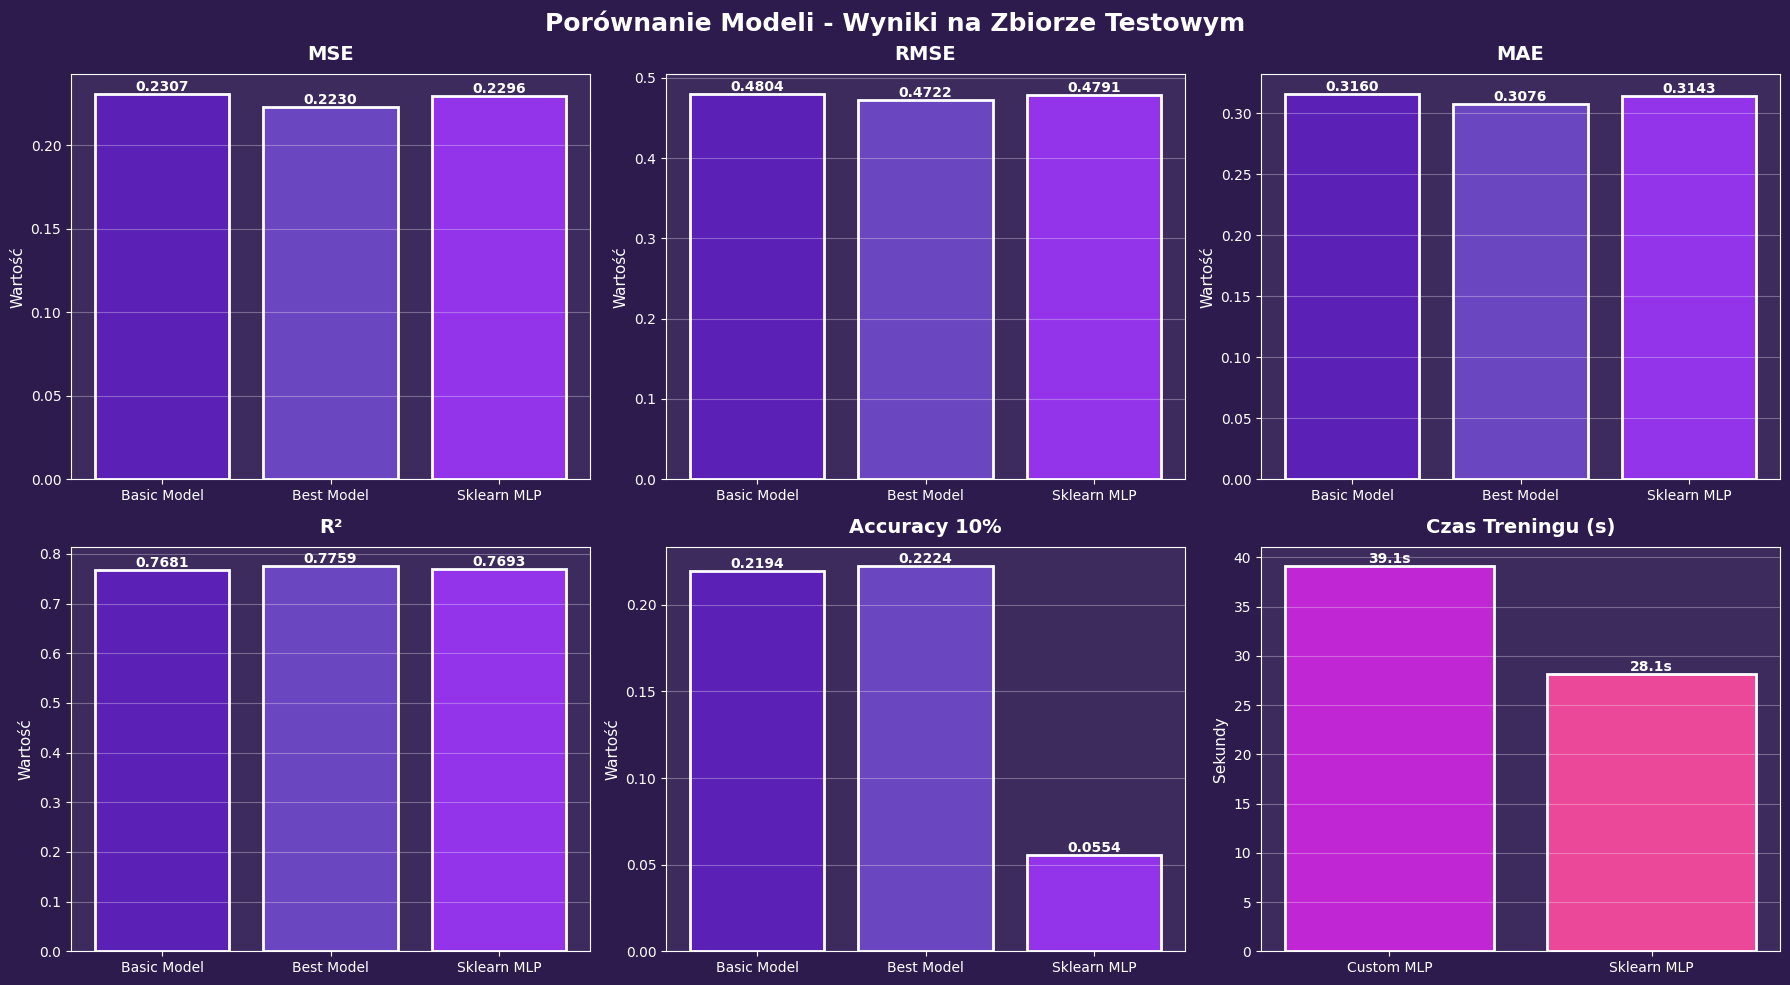

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#2D1B4E')
for ax in axes.flat:
    ax.set_facecolor('#3D2B5E')

metrics = ['mse', 'rmse', 'mae', 'r2', 'accuracy_10pct']
metric_names = ['MSE', 'RMSE', 'MAE', 'R²', 'Accuracy 10%']

# Dane dla porównania
basic_test = reg_results['basic_model']['test']
best_test = reg_results['best_model']
sklearn = reg_results['sklearn_comparison']

basic_model_data = reg_results['basic_model']
basic_model = {
    'train': {
        'mse': basic_model_data['train']['mse_mean'],
        'rmse': basic_model_data['train']['rmse_mean'],
        'mae': basic_model_data['train']['mae_mean'],
        'r2': basic_model_data['train']['r2_mean'],
        'acc': basic_model_data['train']['accuracy_10pct_mean']
    },
    'val': {
        'mse': basic_model_data['val']['mse_mean'],
        'rmse': basic_model_data['val']['rmse_mean'],
        'mae': basic_model_data['val']['mae_mean'],
        'r2': basic_model_data['val']['r2_mean'],
        'acc': basic_model_data['val']['accuracy_10pct_mean']
    },
    'test': {
        'mse': basic_model_data['test']['mse_mean'],
        'rmse': basic_model_data['test']['rmse_mean'],
        'mae': basic_model_data['test']['mae_mean'],
        'r2': basic_model_data['test']['r2_mean'],
        'acc': basic_model_data['test']['accuracy_10pct_mean']
    }
}

models_data = {
    'Basic Model': [basic_test['mse_mean'], basic_test['rmse_mean'], 
                    basic_test['mae_mean'], basic_test['r2_mean'], 
                    basic_test['accuracy_10pct_mean']],
    'Best Model': [best_test['mse_mean'], best_test['rmse_mean'], 
                   best_test['mae_mean'], best_test['r2_mean'], 
                   best_test['accuracy_10pct_mean']],
    'Sklearn MLP': [sklearn['mse']['1'], sklearn['rmse']['1'], 
                    sklearn['mae']['1'], sklearn['r2']['1'], 
                    sklearn['accuracy_10pct']['1']]
}

for idx, (metric, name) in enumerate(zip(metrics, metric_names)):
    ax = axes[idx // 3, idx % 3]
    values = [models_data[model][idx] for model in models_data.keys()]
    bars = ax.bar(models_data.keys(), values, color=GRADIENT[:3], edgecolor='white', linewidth=2)
    ax.set_title(name, fontsize=14, fontweight='bold', color='white', pad=10)
    ax.set_ylabel('Wartość', fontsize=11, color='white')
    ax.tick_params(colors='white')
    ax.grid(axis='y', alpha=0.3, color='white')
    
    # Dodanie wartości na słupkach
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', 
                color='white', fontsize=10, fontweight='bold')

# Porównanie czasu treningu
ax = axes[1, 2]
train_times = [sklearn['train_time']['0'], sklearn['train_time']['1']]
bars = ax.bar(['Custom MLP', 'Sklearn MLP'], train_times, 
              color=[COLORS['accent'], COLORS['pink']], 
              edgecolor='white', linewidth=2)
ax.set_title('Czas Treningu (s)', fontsize=14, fontweight='bold', color='white', pad=10)
ax.set_ylabel('Sekundy', fontsize=11, color='white')
ax.tick_params(colors='white')
ax.grid(axis='y', alpha=0.3, color='white')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}s', ha='center', va='bottom', 
            color='white', fontsize=10, fontweight='bold')

plt.suptitle('Porównanie Modeli - Wyniki na Zbiorze Testowym', 
             fontsize=18, fontweight='bold', color='white', y=0.98)
plt.tight_layout()
plt.show()


Analiza porównawcza na zbiorze testowym wyraźnie wskazuje, że Najlepszy Model (uzyskany po optymalizacji hiperparametrów) osiągnął najwyższą jakość predykcji, notując najniższe błędy oraz najwyższy współczynnik determinacji R². Pomimo, że optymalizowana implementacja Custom MLP wymagała dłuższego czasu treningu ($39.1s$) niż Sklearn MLP ($28.1s$), przyniosła ona znacznie lepsze wyniki w metrykach regresji oraz w dokładności ($22.24\%$ vs $5.54\%$ przy progu $10\%$). Wyniki te dowodzą, że staranne dostrojenie hiperparametrów jest kluczowe dla efektywnej prognozy cen samochodów, przewyższając wydajność zarówno modelu bazowego, jak i standardowej implementacji Sklearn.

---

### Wpływ liczby warstw ukrytych na wyniki

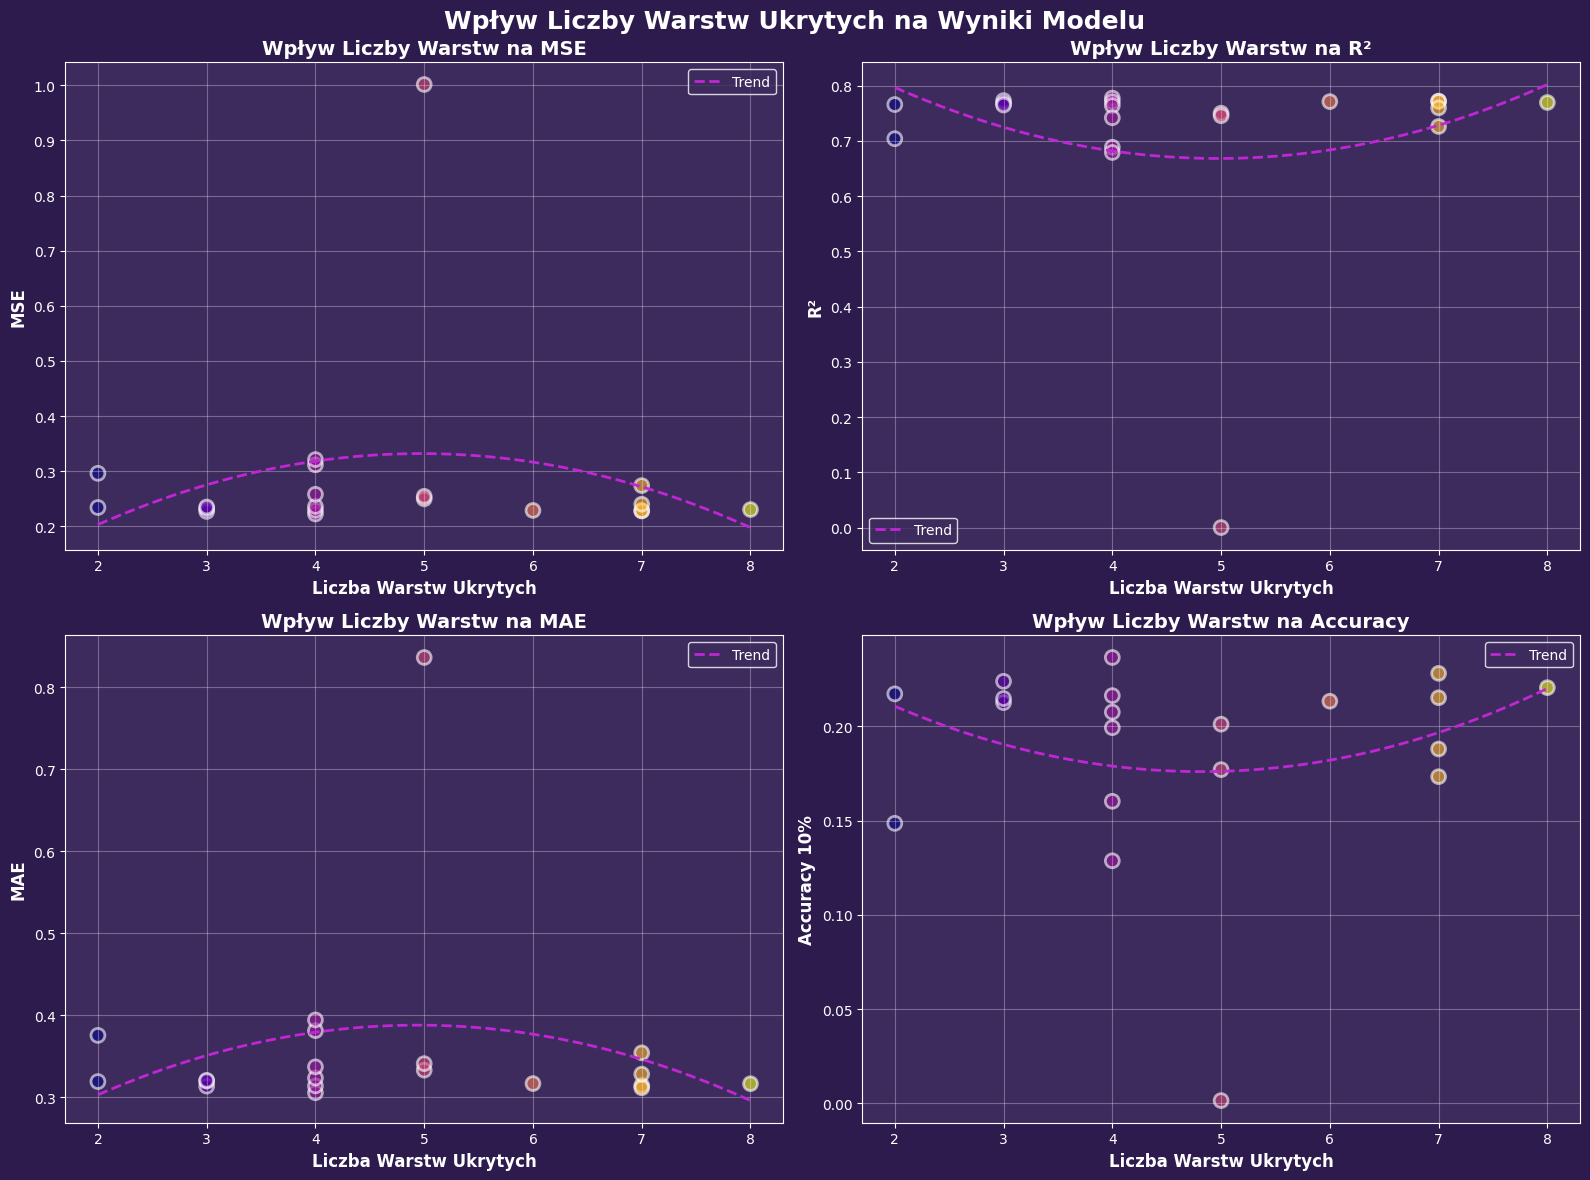

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#2D1B4E')
for ax in axes.flat:
    ax.set_facecolor('#3D2B5E')

random_search = reg_results['random_search']
n_layers = list(map(int, random_search['n_hidden_layers'].values()))
neurons = list(map(int, random_search['n_neurons'].values()))
mse_values = list(random_search['mse_mean'].values())
r2_values = list(random_search['r2_mean'].values())
mae_values = list(random_search['mae_mean'].values())
acc_values = list(random_search['accuracy_10pct_mean'].values())

# Przygotowanie danych dla lepszej wizualizacji
df_layers = pd.DataFrame({
    'n_layers': n_layers,
    'mse': mse_values,
    'r2': r2_values,
    'mae': mae_values,
    'acc': acc_values
})

# Filtracja outlierów dla lepszej wizualizacji
df_clean = df_layers[df_layers['mse'] < 2].copy()

# MSE vs Liczba warstw
ax = axes[0, 0]
scatter = ax.scatter(df_clean['n_layers'], df_clean['mse'], 
                    c=df_clean['n_layers'], cmap='plasma', 
                    s=100, alpha=0.6, edgecolors='white', linewidth=2)
ax.set_xlabel('Liczba Warstw Ukrytych', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('MSE', fontsize=12, fontweight='bold', color='white')
ax.set_title('Wpływ Liczby Warstw na MSE', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.3, color='white')

# Trend line
z = np.polyfit(df_clean['n_layers'], df_clean['mse'], 2)
p = np.poly1d(z)
x_trend = np.linspace(df_clean['n_layers'].min(), df_clean['n_layers'].max(), 100)
ax.plot(x_trend, p(x_trend), color=COLORS['accent'], linewidth=2, linestyle='--', label='Trend')
ax.legend(facecolor='#3D2B5E', edgecolor='white', labelcolor='white')

# R² vs Liczba warstw
ax = axes[0, 1]
scatter = ax.scatter(df_clean['n_layers'], df_clean['r2'], 
                    c=df_clean['n_layers'], cmap='plasma', 
                    s=100, alpha=0.6, edgecolors='white', linewidth=2)
ax.set_xlabel('Liczba Warstw Ukrytych', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('R²', fontsize=12, fontweight='bold', color='white')
ax.set_title('Wpływ Liczby Warstw na R²', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.3, color='white')

z = np.polyfit(df_clean['n_layers'], df_clean['r2'], 2)
p = np.poly1d(z)
ax.plot(x_trend, p(x_trend), color=COLORS['accent'], linewidth=2, linestyle='--', label='Trend')
ax.legend(facecolor='#3D2B5E', edgecolor='white', labelcolor='white')

# MAE vs Liczba warstw
ax = axes[1, 0]
scatter = ax.scatter(df_clean['n_layers'], df_clean['mae'], 
                    c=df_clean['n_layers'], cmap='plasma', 
                    s=100, alpha=0.6, edgecolors='white', linewidth=2)
ax.set_xlabel('Liczba Warstw Ukrytych', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('MAE', fontsize=12, fontweight='bold', color='white')
ax.set_title('Wpływ Liczby Warstw na MAE', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.3, color='white')

z = np.polyfit(df_clean['n_layers'], df_clean['mae'], 2)
p = np.poly1d(z)
ax.plot(x_trend, p(x_trend), color=COLORS['accent'], linewidth=2, linestyle='--', label='Trend')
ax.legend(facecolor='#3D2B5E', edgecolor='white', labelcolor='white')

# Accuracy vs Liczba warstw
ax = axes[1, 1]
scatter = ax.scatter(df_clean['n_layers'], df_clean['acc'], 
                    c=df_clean['n_layers'], cmap='plasma', 
                    s=100, alpha=0.6, edgecolors='white', linewidth=2)
ax.set_xlabel('Liczba Warstw Ukrytych', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('Accuracy 10%', fontsize=12, fontweight='bold', color='white')
ax.set_title('Wpływ Liczby Warstw na Accuracy', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.3, color='white')

z = np.polyfit(df_clean['n_layers'], df_clean['acc'], 2)
p = np.poly1d(z)
ax.plot(x_trend, p(x_trend), color=COLORS['accent'], linewidth=2, linestyle='--', label='Trend')
ax.legend(facecolor='#3D2B5E', edgecolor='white', labelcolor='white')

plt.suptitle('Wpływ Liczby Warstw Ukrytych na Wyniki Modelu', 
             fontsize=18, fontweight='bold', color='white', y=0.98)
plt.tight_layout()
plt.show()

Analiza wykresów ilustrujących wpływ liczby warstw ukrytych na metryki (MSE, R², MAE, Accuracy) w modelach generowanych przez Random Search wykazuje, że nie ma prostej, liniowej zależności między głębokością sieci a jej wydajnością. Najlepsze rezultaty są osiągane przez konfiguracje z małą (2-3) lub dużą (7-8) liczbą warstw, gdzie widać najwyższe wartości R² (bliskie $0.8$) i najniższe błędy. 

---

### Wpływ learning rate na wyniki

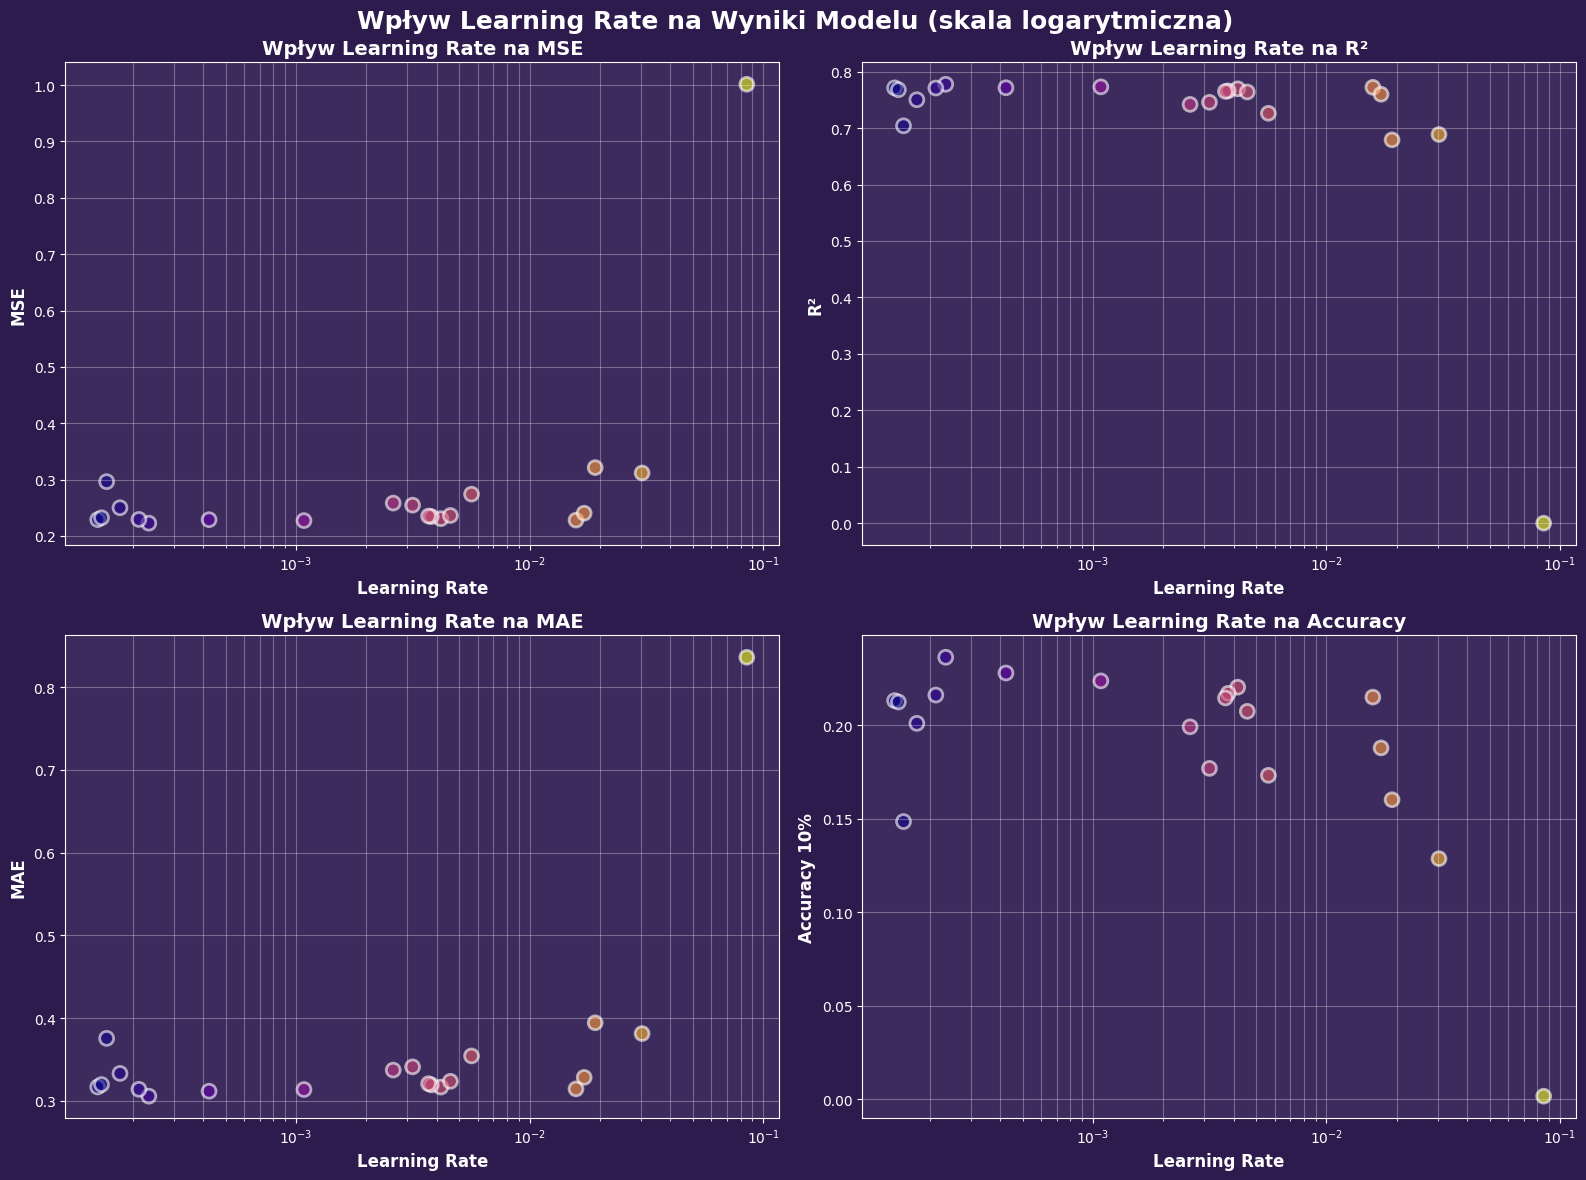

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#2D1B4E')
for ax in axes.flat:
    ax.set_facecolor('#3D2B5E')

learning_rates = list(random_search['learning_rate'].values())

df_lr = pd.DataFrame({
    'lr': learning_rates,
    'mse': mse_values,
    'r2': r2_values,
    'mae': mae_values,
    'acc': acc_values
})

# Filtracja outlierów
df_lr_clean = df_lr[df_lr['mse'] < 2].copy()

# MSE vs Learning Rate (log scale)
ax = axes[0, 0]
scatter = ax.scatter(df_lr_clean['lr'], df_lr_clean['mse'], 
                    c=np.log10(df_lr_clean['lr']), cmap='plasma', 
                    s=100, alpha=0.6, edgecolors='white', linewidth=2)
ax.set_xlabel('Learning Rate', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('MSE', fontsize=12, fontweight='bold', color='white')
ax.set_title('Wpływ Learning Rate na MSE', fontsize=14, fontweight='bold', color='white')
ax.set_xscale('log')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.3, color='white', which='both')

# R² vs Learning Rate
ax = axes[0, 1]
scatter = ax.scatter(df_lr_clean['lr'], df_lr_clean['r2'], 
                    c=np.log10(df_lr_clean['lr']), cmap='plasma', 
                    s=100, alpha=0.6, edgecolors='white', linewidth=2)
ax.set_xlabel('Learning Rate', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('R²', fontsize=12, fontweight='bold', color='white')
ax.set_title('Wpływ Learning Rate na R²', fontsize=14, fontweight='bold', color='white')
ax.set_xscale('log')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.3, color='white', which='both')

# MAE vs Learning Rate
ax = axes[1, 0]
scatter = ax.scatter(df_lr_clean['lr'], df_lr_clean['mae'], 
                    c=np.log10(df_lr_clean['lr']), cmap='plasma', 
                    s=100, alpha=0.6, edgecolors='white', linewidth=2)
ax.set_xlabel('Learning Rate', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('MAE', fontsize=12, fontweight='bold', color='white')
ax.set_title('Wpływ Learning Rate na MAE', fontsize=14, fontweight='bold', color='white')
ax.set_xscale('log')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.3, color='white', which='both')

# Accuracy vs Learning Rate
ax = axes[1, 1]
scatter = ax.scatter(df_lr_clean['lr'], df_lr_clean['acc'], 
                    c=np.log10(df_lr_clean['lr']), cmap='plasma', 
                    s=100, alpha=0.6, edgecolors='white', linewidth=2)
ax.set_xlabel('Learning Rate', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('Accuracy 10%', fontsize=12, fontweight='bold', color='white')
ax.set_title('Wpływ Learning Rate na Accuracy', fontsize=14, fontweight='bold', color='white')
ax.set_xscale('log')
ax.tick_params(colors='white')
ax.grid(True, alpha=0.3, color='white', which='both')

plt.suptitle('Wpływ Learning Rate na Wyniki Modelu (skala logarytmiczna)', 
             fontsize=18, fontweight='bold', color='white', y=0.98)
plt.tight_layout()
plt.show()



Analiza wpływu Learning Rate na wydajność modelu wyraźnie wskazuje, że optymalny zakres tego hiperparametru znajduje się między $10^{-4}$ a $10^{-2}$, gdzie modele osiągają najwyższe współczynniki R² (blisko $0.8$) i najniższe błędy regresji. Użycie zbyt dużej wartości, rzędu $10^{-1}$, prowadzi do całkowitej destabilizacji procesu treningowego, skutkując niemal zerową dokładnością i katastrofalnie wysokimi błędami (np. MSE bliskie $1.0$). To potwierdza, że precyzyjny dobór niskiego współczynnika uczenia jest krytyczny dla konwergencji sieci MLP i osiągnięcia zadowalającej jakości prognoz cen.

---

## Porównanie optymalizatorów

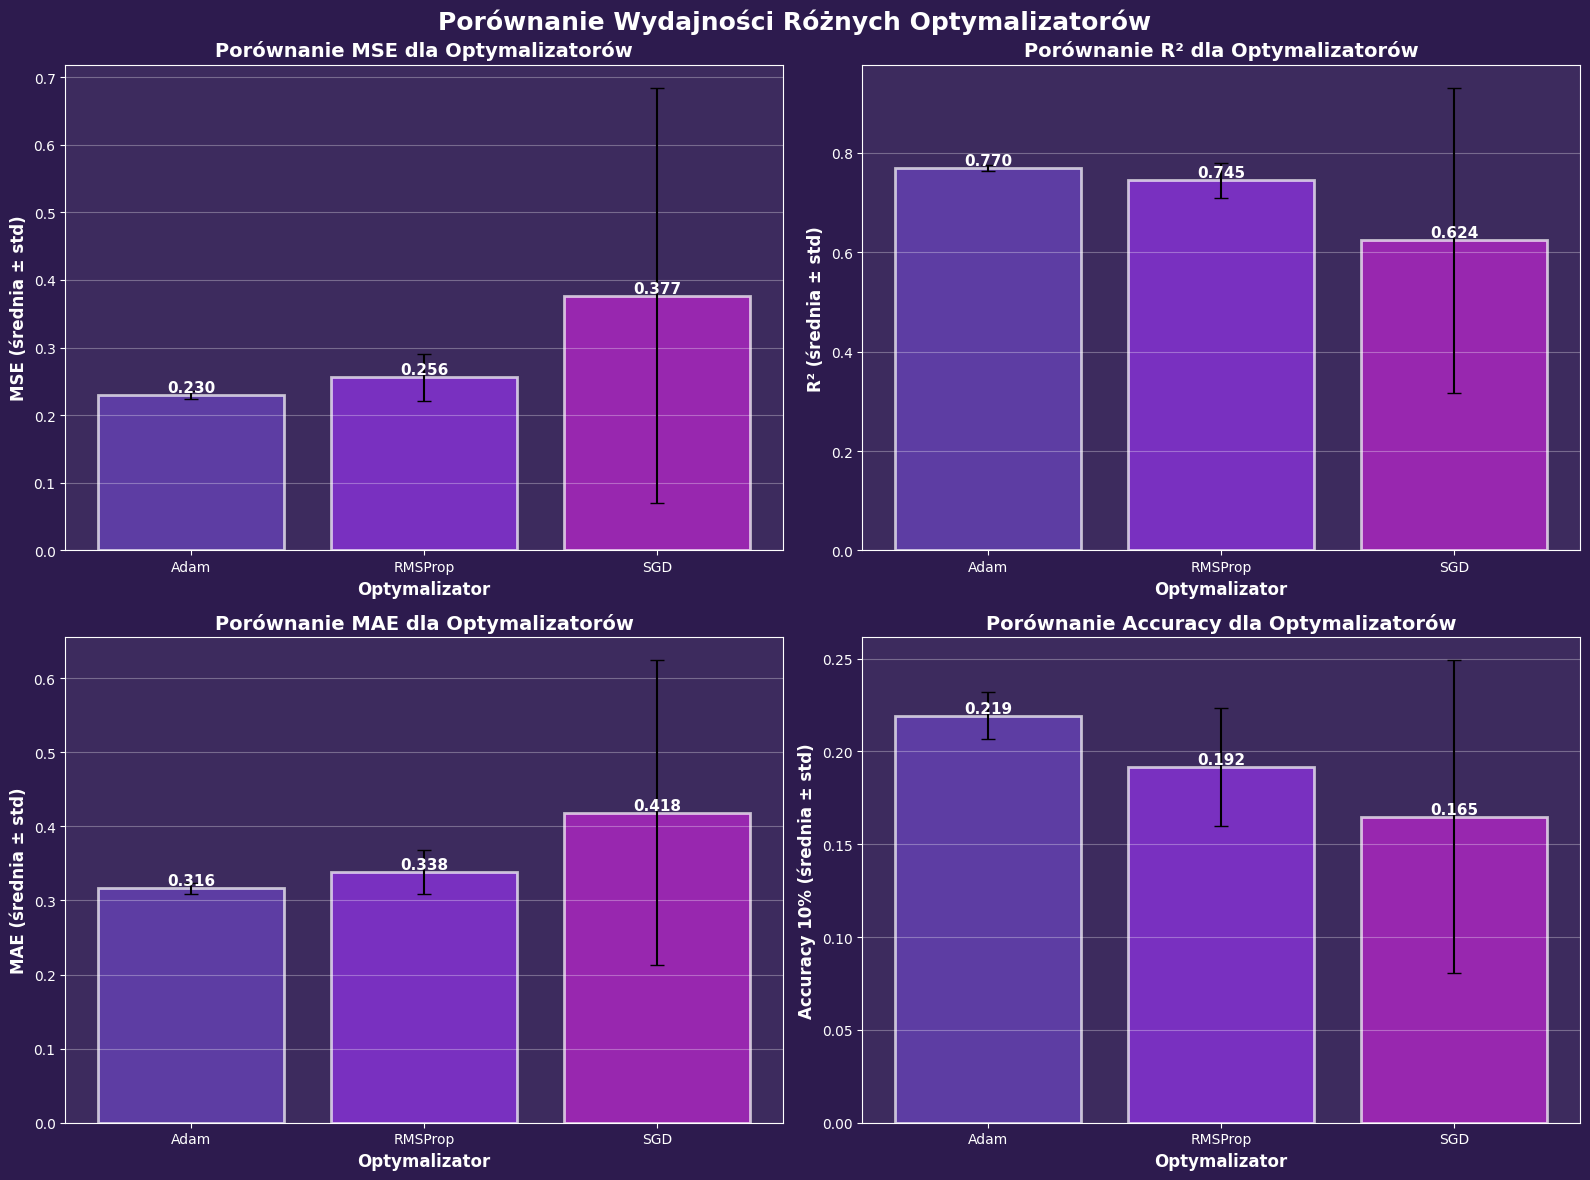

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#2D1B4E')
for ax in axes.flat:
    ax.set_facecolor('#3D2B5E')

optimizers = list(random_search['optimizer'].values())
df_opt = pd.DataFrame({
    'optimizer': optimizers,
    'mse': mse_values,
    'r2': r2_values,
    'mae': mae_values,
    'acc': acc_values
})

# Filtracja outlierów
df_opt_clean = df_opt[df_opt['mse'] < 2].copy()

# Grupowanie po optymalizatorach
opt_stats = df_opt_clean.groupby('optimizer').agg({
    'mse': ['mean', 'std', 'min'],
    'r2': ['mean', 'std', 'max'],
    'mae': ['mean', 'std', 'min'],
    'acc': ['mean', 'std', 'max']
}).reset_index()

opt_names = opt_stats['optimizer'].values
colors_opt = [COLORS['primary'], COLORS['secondary'], COLORS['accent']]

# MSE per optimizer
ax = axes[0, 0]
bars = ax.bar(opt_names, opt_stats['mse']['mean'], 
              yerr=opt_stats['mse']['std'], 
              color=colors_opt, alpha=0.7, 
              edgecolor='white', linewidth=2, capsize=5)
ax.set_xlabel('Optymalizator', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('MSE (średnia ± std)', fontsize=12, fontweight='bold', color='white')
ax.set_title('Porównanie MSE dla Optymalizatorów', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white')
ax.grid(axis='y', alpha=0.3, color='white')

for bar, val in zip(bars, opt_stats['mse']['mean']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', 
            color='white', fontsize=11, fontweight='bold')

# R² per optimizer
ax = axes[0, 1]
bars = ax.bar(opt_names, opt_stats['r2']['mean'], 
              yerr=opt_stats['r2']['std'], 
              color=colors_opt, alpha=0.7, 
              edgecolor='white', linewidth=2, capsize=5)
ax.set_xlabel('Optymalizator', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('R² (średnia ± std)', fontsize=12, fontweight='bold', color='white')
ax.set_title('Porównanie R² dla Optymalizatorów', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white')
ax.grid(axis='y', alpha=0.3, color='white')

for bar, val in zip(bars, opt_stats['r2']['mean']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', 
            color='white', fontsize=11, fontweight='bold')

# MAE per optimizer
ax = axes[1, 0]
bars = ax.bar(opt_names, opt_stats['mae']['mean'], 
              yerr=opt_stats['mae']['std'], 
              color=colors_opt, alpha=0.7, 
              edgecolor='white', linewidth=2, capsize=5)
ax.set_xlabel('Optymalizator', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('MAE (średnia ± std)', fontsize=12, fontweight='bold', color='white')
ax.set_title('Porównanie MAE dla Optymalizatorów', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white')
ax.grid(axis='y', alpha=0.3, color='white')

for bar, val in zip(bars, opt_stats['mae']['mean']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', 
            color='white', fontsize=11, fontweight='bold')

# Accuracy per optimizer
ax = axes[1, 1]
bars = ax.bar(opt_names, opt_stats['acc']['mean'], 
              yerr=opt_stats['acc']['std'], 
              color=colors_opt, alpha=0.7, 
              edgecolor='white', linewidth=2, capsize=5)
ax.set_xlabel('Optymalizator', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('Accuracy 10% (średnia ± std)', fontsize=12, fontweight='bold', color='white')
ax.set_title('Porównanie Accuracy dla Optymalizatorów', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white')
ax.grid(axis='y', alpha=0.3, color='white')

for bar, val in zip(bars, opt_stats['acc']['mean']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', 
            color='white', fontsize=11, fontweight='bold')

plt.suptitle('Porównanie Wydajności Różnych Optymalizatorów', 
             fontsize=18, fontweight='bold', color='white', y=0.98)
plt.tight_layout()
plt.show()



Analiza porównawcza optymalizatorów dla modelu MLP jasno wskazuje, że Adam jest zdecydowanie najlepszym wyborem dla tego zadania prognozowania cen samochodów. Optymalizator Adam osiągnął najwyższy współczynnik determinacji R² (0.770) oraz najniższe błędy MSE (0.230) i MAE (0.316), jednocześnie wykazując największą stabilność, mierzoną najmniejszym odchyleniem standardowym. 

---

### Porównanie funkcji aktywacji

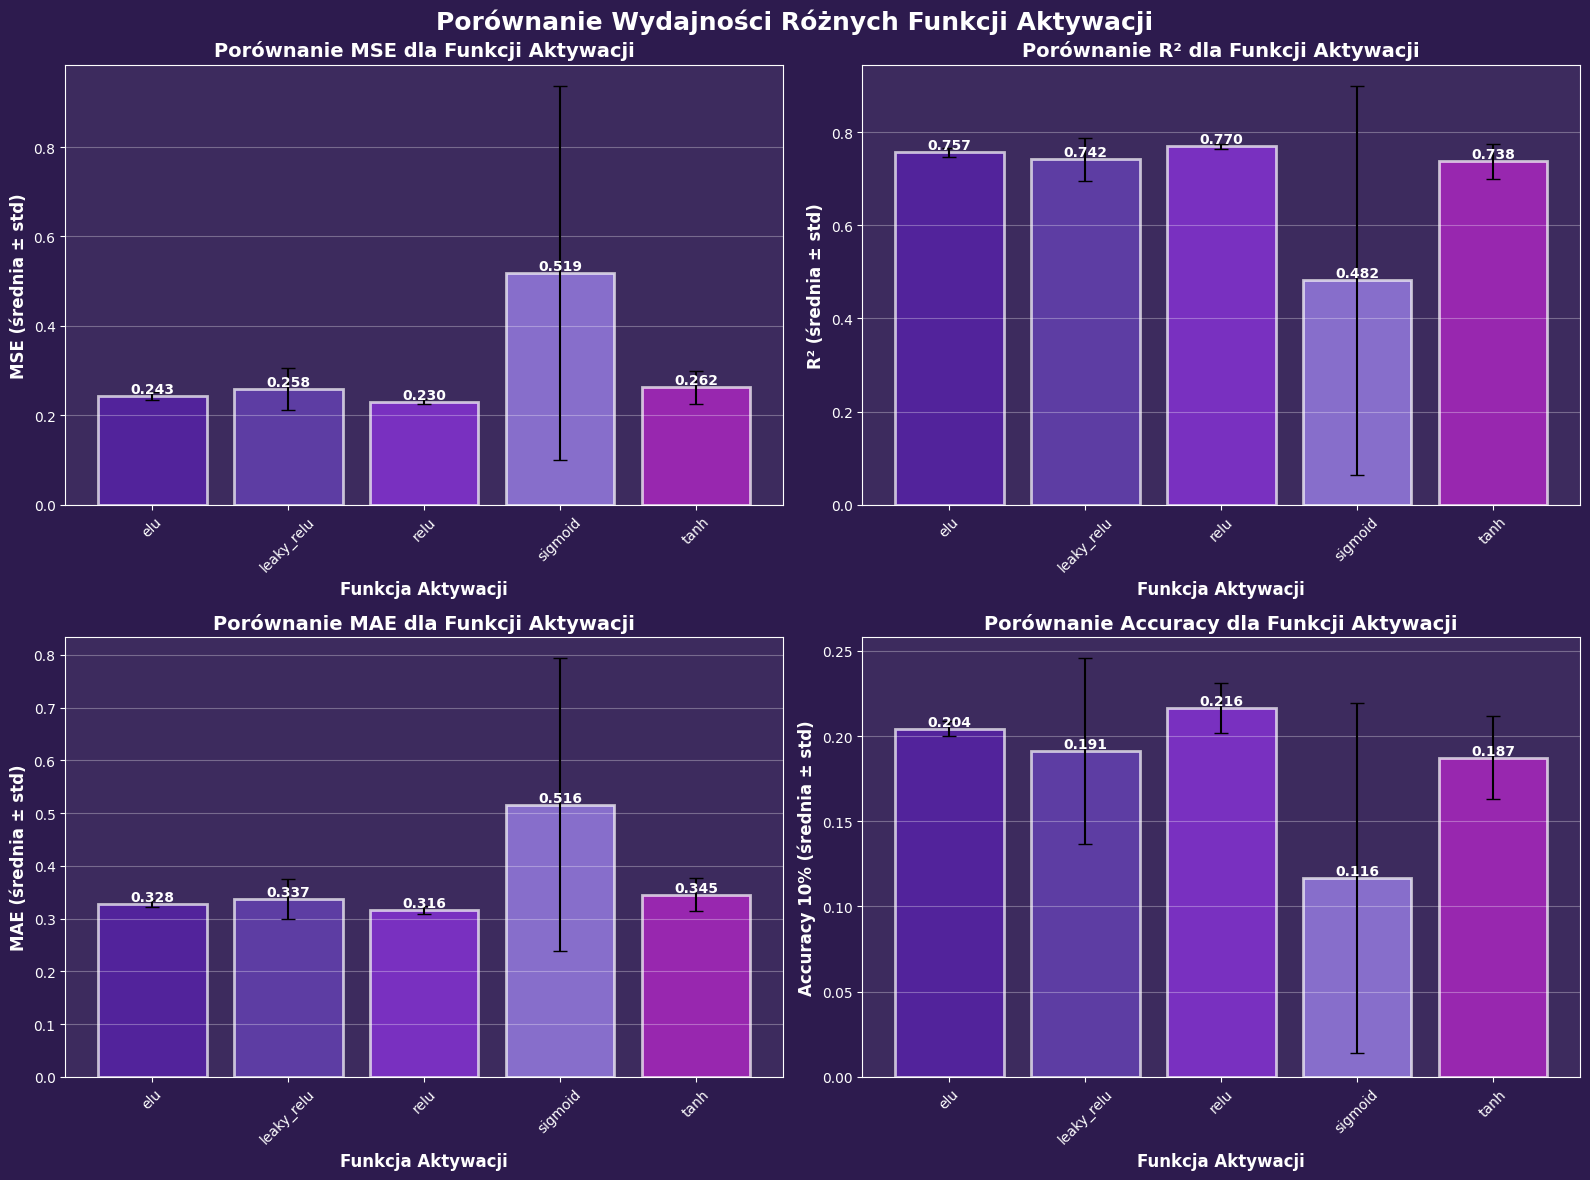

In [22]:

# 5. PORÓWNANIE FUNKCJI AKTYWACJI

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#2D1B4E')
for ax in axes.flat:
    ax.set_facecolor('#3D2B5E')

activations = list(random_search['activation'].values())
df_act = pd.DataFrame({
    'activation': activations,
    'mse': mse_values,
    'r2': r2_values,
    'mae': mae_values,
    'acc': acc_values
})

# Filtracja outlierów
df_act_clean = df_act[df_act['mse'] < 2].copy()

# Grupowanie po funkcjach aktywacji
act_stats = df_act_clean.groupby('activation').agg({
    'mse': ['mean', 'std', 'min'],
    'r2': ['mean', 'std', 'max'],
    'mae': ['mean', 'std', 'min'],
    'acc': ['mean', 'std', 'max']
}).reset_index()

act_names = act_stats['activation'].values
colors_act = GRADIENT[:len(act_names)]

# MSE per activation
ax = axes[0, 0]
bars = ax.bar(act_names, act_stats['mse']['mean'], 
              yerr=act_stats['mse']['std'], 
              color=colors_act, alpha=0.7, 
              edgecolor='white', linewidth=2, capsize=5)
ax.set_xlabel('Funkcja Aktywacji', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('MSE (średnia ± std)', fontsize=12, fontweight='bold', color='white')
ax.set_title('Porównanie MSE dla Funkcji Aktywacji', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white', axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3, color='white')

for bar, val in zip(bars, act_stats['mse']['mean']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', 
            color='white', fontsize=10, fontweight='bold')

# R² per activation
ax = axes[0, 1]
bars = ax.bar(act_names, act_stats['r2']['mean'], 
              yerr=act_stats['r2']['std'], 
              color=colors_act, alpha=0.7, 
              edgecolor='white', linewidth=2, capsize=5)
ax.set_xlabel('Funkcja Aktywacji', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('R² (średnia ± std)', fontsize=12, fontweight='bold', color='white')
ax.set_title('Porównanie R² dla Funkcji Aktywacji', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white', axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3, color='white')

for bar, val in zip(bars, act_stats['r2']['mean']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', 
            color='white', fontsize=10, fontweight='bold')

# MAE per activation
ax = axes[1, 0]
bars = ax.bar(act_names, act_stats['mae']['mean'], 
              yerr=act_stats['mae']['std'], 
              color=colors_act, alpha=0.7, 
              edgecolor='white', linewidth=2, capsize=5)
ax.set_xlabel('Funkcja Aktywacji', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('MAE (średnia ± std)', fontsize=12, fontweight='bold', color='white')
ax.set_title('Porównanie MAE dla Funkcji Aktywacji', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white', axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3, color='white')

for bar, val in zip(bars, act_stats['mae']['mean']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', 
            color='white', fontsize=10, fontweight='bold')

# Accuracy per activation
ax = axes[1, 1]
bars = ax.bar(act_names, act_stats['acc']['mean'], 
              yerr=act_stats['acc']['std'], 
              color=colors_act, alpha=0.7, 
              edgecolor='white', linewidth=2, capsize=5)
ax.set_xlabel('Funkcja Aktywacji', fontsize=12, fontweight='bold', color='white')
ax.set_ylabel('Accuracy 10% (średnia ± std)', fontsize=12, fontweight='bold', color='white')
ax.set_title('Porównanie Accuracy dla Funkcji Aktywacji', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white', axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3, color='white')

for bar, val in zip(bars, act_stats['acc']['mean']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', 
            color='white', fontsize=10, fontweight='bold')

plt.suptitle('Porównanie Wydajności Różnych Funkcji Aktywacji', 
             fontsize=18, fontweight='bold', color='white', y=0.98)
plt.tight_layout()
plt.show()

Najlepsze i najbardziej stabilne wyniki osiągają funkcje ReLU i elu. Funkcja ReLU wykazała się nieznacznie najwyższym współczynnikiem determinacji R² ($0.770$) i najlepszą dokładnością Accuracy ($0.216$), jednocześnie notując niskie błędy MSE ($0.230$) i MAE ($0.316$).

---

### Rozkład metryk dla różnych konfiguracji

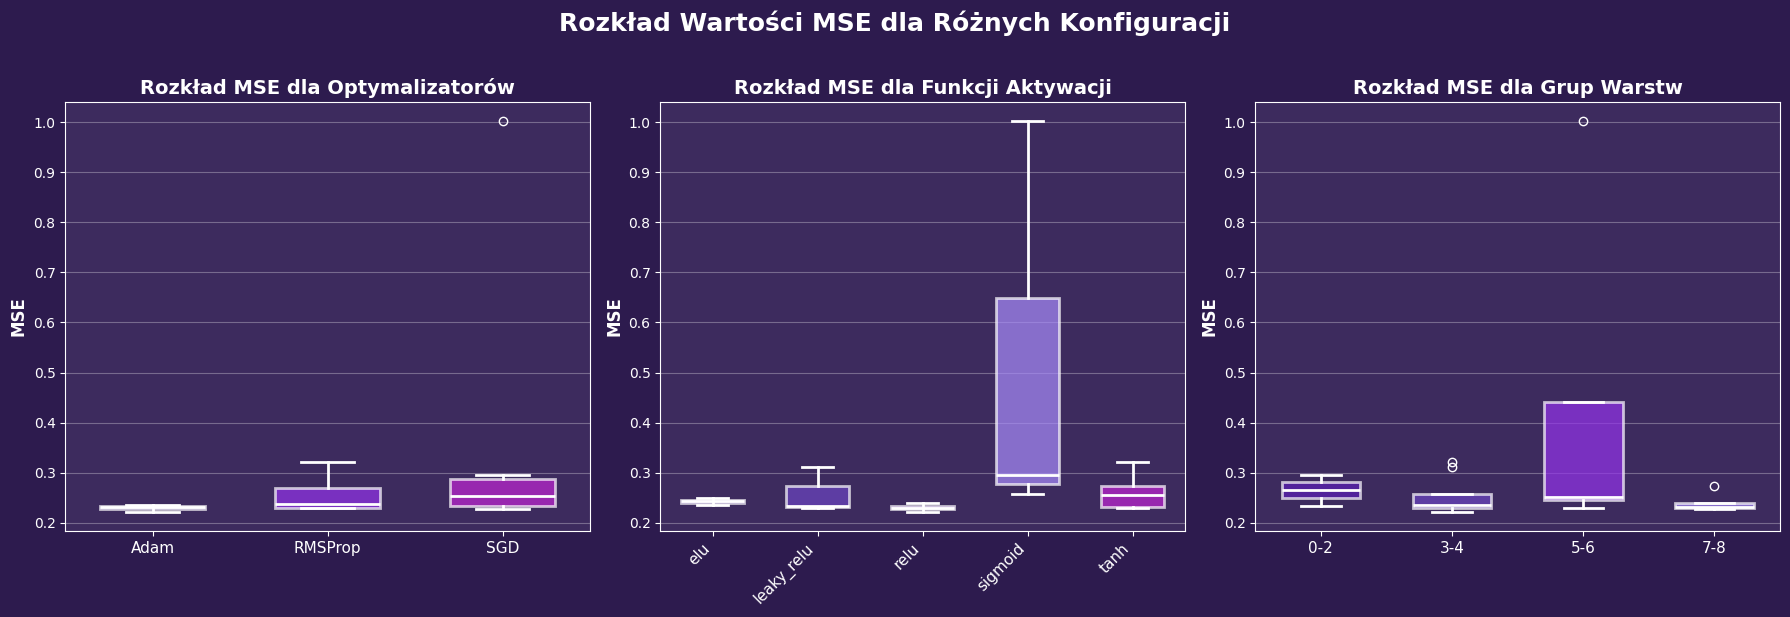

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#2D1B4E')
for ax in axes.flat:
    ax.set_facecolor('#3D2B5E')

# Boxplot dla optymalizatorów
ax = axes[0]
df_opt_clean_grouped = df_opt_clean.groupby('optimizer')['mse'].apply(list)
positions = range(len(df_opt_clean_grouped))
bp = ax.boxplot(df_opt_clean_grouped.values, positions=positions, 
                patch_artist=True, widths=0.6)

for patch, color in zip(bp['boxes'], colors_opt):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('white')
    patch.set_linewidth(2)

for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    plt.setp(bp[element], color='white', linewidth=2)

ax.set_xticklabels(df_opt_clean_grouped.index, fontsize=11, color='white')
ax.set_ylabel('MSE', fontsize=12, fontweight='bold', color='white')
ax.set_title('Rozkład MSE dla Optymalizatorów', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white')
ax.grid(axis='y', alpha=0.3, color='white')

# Boxplot dla funkcji aktywacji
ax = axes[1]
df_act_clean_grouped = df_act_clean.groupby('activation')['mse'].apply(list)
positions = range(len(df_act_clean_grouped))
bp = ax.boxplot(df_act_clean_grouped.values, positions=positions, 
                patch_artist=True, widths=0.6)

for patch, color in zip(bp['boxes'], colors_act[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('white')
    patch.set_linewidth(2)

for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    plt.setp(bp[element], color='white', linewidth=2)

ax.set_xticklabels(df_act_clean_grouped.index, fontsize=11, color='white', rotation=45, ha='right')
ax.set_ylabel('MSE', fontsize=12, fontweight='bold', color='white')
ax.set_title('Rozkład MSE dla Funkcji Aktywacji', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white')
ax.grid(axis='y', alpha=0.3, color='white')

# Boxplot dla zakresów liczby warstw
ax = axes[2]
df_layers_grouped = df_clean.copy()
df_layers_grouped['layer_group'] = pd.cut(df_layers_grouped['n_layers'], 
                                           bins=[0, 2, 4, 6, 8], 
                                           labels=['0-2', '3-4', '5-6', '7-8'])
layer_groups = df_layers_grouped.groupby('layer_group')['mse'].apply(list)
positions = range(len(layer_groups))
bp = ax.boxplot(layer_groups.values, positions=positions, 
                patch_artist=True, widths=0.6)

for patch, color in zip(bp['boxes'], GRADIENT):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('white')
    patch.set_linewidth(2)

for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    plt.setp(bp[element], color='white', linewidth=2)

ax.set_xticklabels(layer_groups.index, fontsize=11, color='white')
ax.set_ylabel('MSE', fontsize=12, fontweight='bold', color='white')
ax.set_title('Rozkład MSE dla Grup Warstw', fontsize=14, fontweight='bold', color='white')
ax.tick_params(colors='white')
ax.grid(axis='y', alpha=0.3, color='white')

plt.suptitle('Rozkład Wartości MSE dla Różnych Konfiguracji', 
             fontsize=18, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

Wykresy skrzynkowe rozkładu błędu MSE potwierdzają kluczowe wnioski dotyczące stabilności i wydajności hiperparametrów, wzmacniając rezultaty analizy średnich. Optymalizator Adam oraz funkcja aktywacji ReLU wykazują najniższe mediany MSE i najmniejszy rozrzut (najkrótsze skrzynki), co świadczy o ich największej stabilności i konsekwentnie niskim błędzie. Natomiast funkcja sigmoid jest najbardziej niestabilna, charakteryzując się szerokim rozstępem międzykwartylowym oraz najwyższą medianą MSE. Wpływ głębokości sieci potwierdza, że konfiguracje 5-6 warstw są najmniej stabilne (szeroka skrzynka i wysoka mediana), podczas gdy skrajne grupy 0-2 oraz 7-8 warstw są najbardziej stabilne i efektywne pod względem mediany błędu.

--- 

### Wyniki różnych konfiguracji

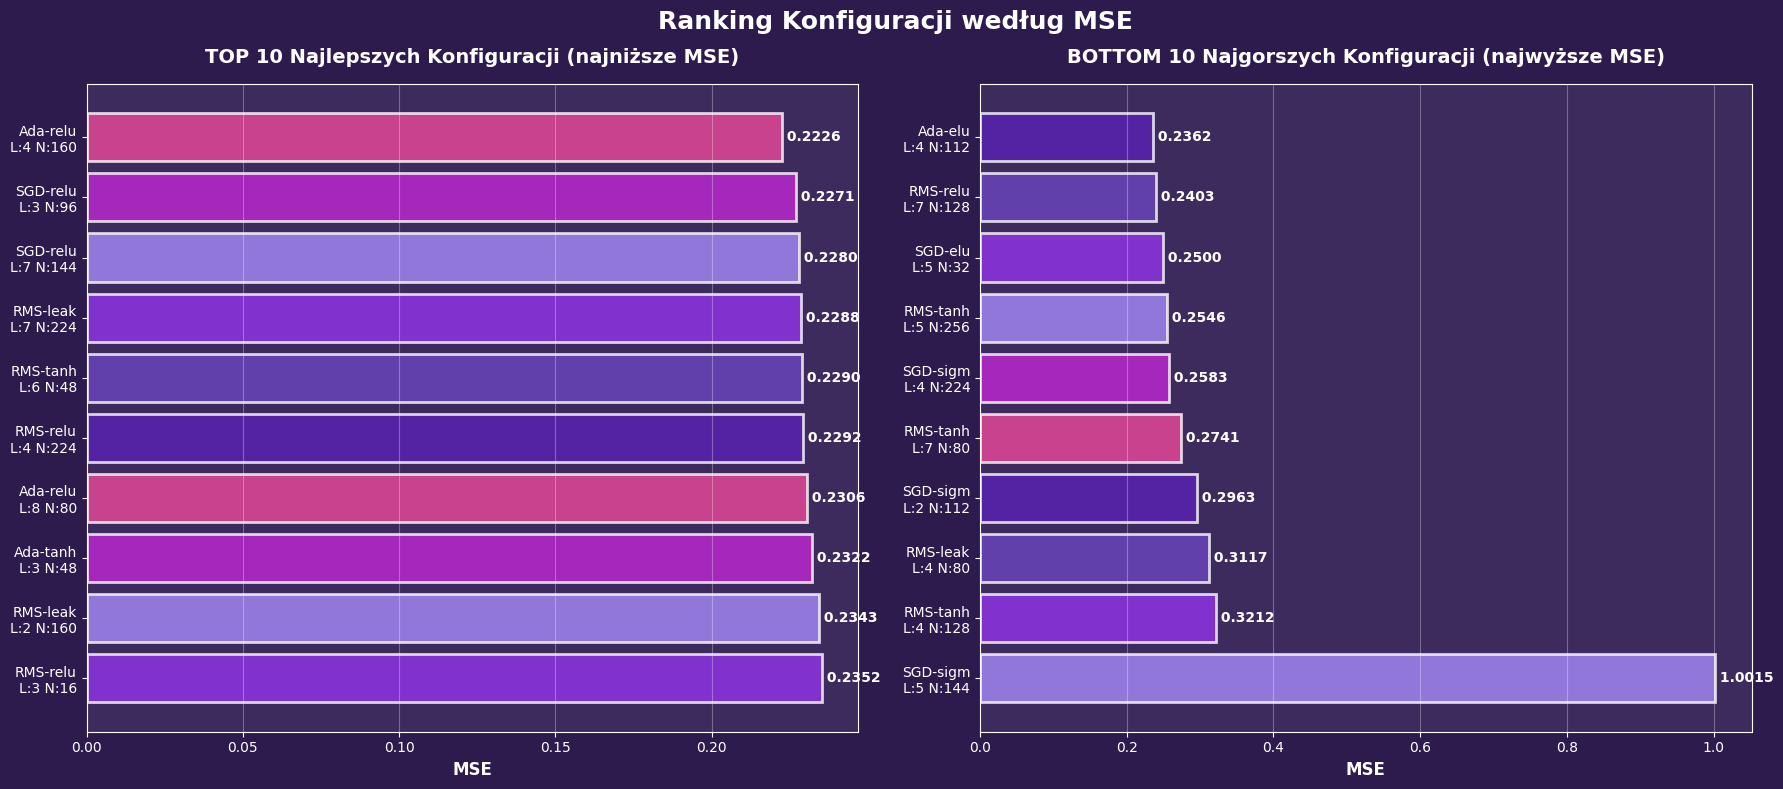

In [24]:

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#2D1B4E')
for ax in axes.flat:
    ax.set_facecolor('#3D2B5E')

# Przygotowanie danych
configs = []
for i in range(len(mse_values)):
    if mse_values[i] < 2:  # filtracja outlierów
        configs.append({
            'id': i,
            'mse': mse_values[i],
            'r2': r2_values[i],
            'optimizer': optimizers[i],
            'activation': activations[i],
            'layers': n_layers[i],
            'neurons': neurons[i]
        })

df_configs = pd.DataFrame(configs)
df_configs_sorted = df_configs.sort_values('mse')

# TOP 10 (najlepsze - najniższe MSE)
ax = axes[0]
top10 = df_configs_sorted.head(10).copy()
top10['config_name'] = top10.apply(
    lambda x: f"{x['optimizer'][:3]}-{x['activation'][:4]}\nL:{x['layers']} N:{x['neurons']}", 
    axis=1
)

bars = ax.barh(range(10), top10['mse'], color=GRADIENT[:10][::-1], 
               edgecolor='white', linewidth=2, alpha=0.8)
ax.set_yticks(range(10))
ax.set_yticklabels(top10['config_name'].values, fontsize=10, color='white')
ax.set_xlabel('MSE', fontsize=12, fontweight='bold', color='white')
ax.set_title('TOP 10 Najlepszych Konfiguracji (najniższe MSE)', 
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.tick_params(colors='white')
ax.grid(axis='x', alpha=0.3, color='white')
ax.invert_yaxis()

for i, (bar, val) in enumerate(zip(bars, top10['mse'])):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' {val:.4f}', ha='left', va='center', 
            color='white', fontsize=10, fontweight='bold')

# BOTTOM 10 (najgorsze - najwyższe MSE)
ax = axes[1]
bottom10 = df_configs_sorted.tail(10).copy()
bottom10['config_name'] = bottom10.apply(
    lambda x: f"{x['optimizer'][:3]}-{x['activation'][:4]}\nL:{x['layers']} N:{x['neurons']}", 
    axis=1
)

bars = ax.barh(range(10), bottom10['mse'], color=GRADIENT[:10], 
               edgecolor='white', linewidth=2, alpha=0.8)
ax.set_yticks(range(10))
ax.set_yticklabels(bottom10['config_name'].values, fontsize=10, color='white')
ax.set_xlabel('MSE', fontsize=12, fontweight='bold', color='white')
ax.set_title('BOTTOM 10 Najgorszych Konfiguracji (najwyższe MSE)', 
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.tick_params(colors='white')
ax.grid(axis='x', alpha=0.3, color='white')
ax.invert_yaxis()

for i, (bar, val) in enumerate(zip(bars, bottom10['mse'])):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' {val:.4f}', ha='left', va='center', 
            color='white', fontsize=10, fontweight='bold')

plt.suptitle('Ranking Konfiguracji według MSE', 
             fontsize=18, fontweight='bold', color='white', y=0.98)
plt.tight_layout()
plt.show()

 Najlepsze 10 konfiguracji osiąga bardzo niskie i zbliżone błędy MSE (od $0.2226$ do $0.2352$), przy czym dominują w nich optymalizatory Adam i RMSProp w połączeniu z funkcjami aktywacji ReLU lub elu, co potwierdza ich stabilność i wysoką wydajność. Z drugiej strony, 10 najgorszych konfiguracji ma błędy sięgające nawet $1.0015$, a największe błędy są często związane z użyciem funkcji sigmoid oraz niestabilnych kombinacji (np. SGD-sigmoid), co prowadzi do drastycznej i nieakceptowalnej degradacji precyzji predykcji cen samochodów.

 ---

 ### Podsumowanie

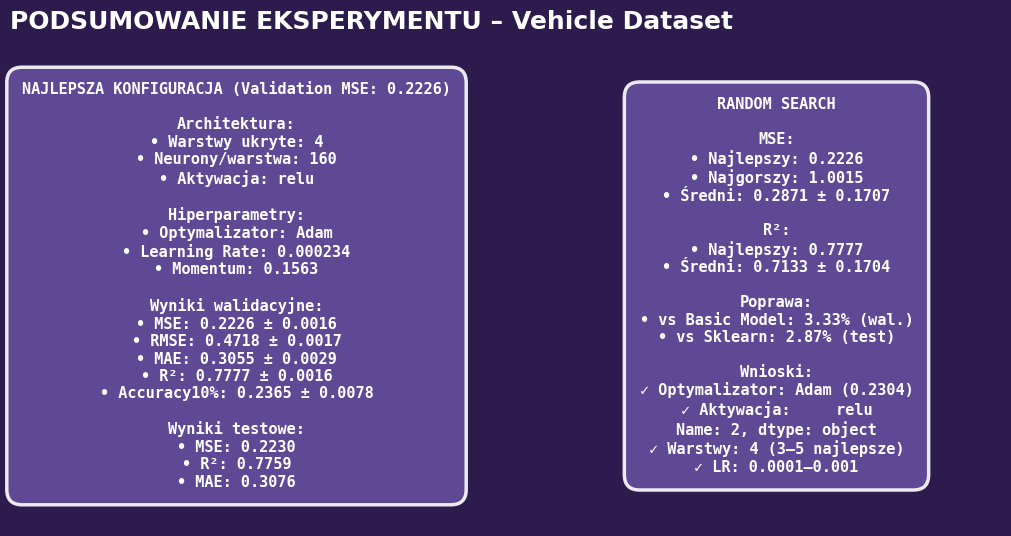

In [25]:
fig = plt.figure(figsize=(14, 6))
fig.patch.set_facecolor('#2D1B4E')

gs = fig.add_gridspec(1, 5, wspace=0.5)

ax1 = fig.add_subplot(gs[0, 1:3]) 
ax1.set_facecolor('#3D2B5E')
ax1.axis('off')

best_config = reg_results['best_model']['config']

config_text = f"""
NAJLEPSZA KONFIGURACJA (Validation MSE: {best_config['mse_mean']:.4f})

Architektura:
• Warstwy ukryte: {best_config['n_hidden_layers']}
• Neurony/warstwa: {best_config['n_neurons']}
• Aktywacja: {best_config['activation']}

Hiperparametry:
• Optymalizator: {best_config['optimizer']}
• Learning Rate: {best_config['learning_rate']:.6f}
• Momentum: {best_config['momentum']:.4f}

Wyniki walidacyjne:
• MSE: {best_config['mse_mean']:.4f} ± {best_config['mse_std']:.4f}
• RMSE: {best_config['rmse_mean']:.4f} ± {best_config['rmse_std']:.4f}
• MAE: {best_config['mae_mean']:.4f} ± {best_config['mae_std']:.4f}
• R²: {best_config['r2_mean']:.4f} ± {best_config['r2_std']:.4f}
• Accuracy10%: {best_config['accuracy_10pct_mean']:.4f} ± {best_config['accuracy_10pct_std']:.4f}

Wyniki testowe:
• MSE: {reg_results['best_model']['mse_mean']:.4f}
• R²: {reg_results['best_model']['r2_mean']:.4f}
• MAE: {reg_results['best_model']['mae_mean']:.4f}
"""

ax1.text(0.5, 0.5, config_text.strip(), transform=ax1.transAxes,
         fontsize=11, va='center', ha='center', wrap=True,
         bbox=dict(boxstyle='round,pad=1.0', facecolor='#654E9C',
                   edgecolor='white', linewidth=2.5, alpha=0.9),
         color='white', fontfamily='monospace', fontweight='bold')

ax2 = fig.add_subplot(gs[0, 3:5])  
ax2.set_facecolor('#3D2B5E')
ax2.axis('off')

df_all_clean = pd.DataFrame({
    'mse': [m for m in mse_values if m < 2],
    'r2': [r for m, r in zip(mse_values, r2_values) if m < 2]
})

stats_text = f"""
RANDOM SEARCH

MSE:
• Najlepszy: {df_all_clean['mse'].min():.4f}
• Najgorszy: {df_all_clean['mse'].max():.4f}
• Średni: {df_all_clean['mse'].mean():.4f} ± {df_all_clean['mse'].std():.4f}

R²:
• Najlepszy: {df_all_clean['r2'].max():.4f}
• Średni: {df_all_clean['r2'].mean():.4f} ± {df_all_clean['r2'].std():.4f}

Poprawa:
• vs Basic Model: {((basic_model['val']['mse'] - best_config['mse_mean']) / basic_model['val']['mse'] * 100):.2f}% (wal.)
• vs Sklearn: {((sklearn['mse']['1'] - reg_results['best_model']['mse_mean']) / sklearn['mse']['1'] * 100):.2f}% (test)

Wnioski:
✓ Optymalizator: Adam ({opt_stats[opt_stats['optimizer'] == 'Adam']['mse']['mean'].values[0]:.4f})
✓ Aktywacja: {act_stats.iloc[act_stats['mse']['mean'].argmin()]['activation']}
✓ Warstwy: {best_config['n_hidden_layers']} (3–5 najlepsze)
✓ LR: 0.0001–0.001
"""

ax2.text(0.5, 0.5, stats_text.strip(), transform=ax2.transAxes,
         fontsize=11, va='center', ha='center', wrap=True,
         bbox=dict(boxstyle='round,pad=1.0', facecolor='#654E9C',
                   edgecolor='white', linewidth=2.5, alpha=0.9),
         color='white', fontfamily='monospace', fontweight='bold')

plt.suptitle('PODSUMOWANIE EKSPERYMENTU – Vehicle Dataset',
             fontsize=18, fontweight='bold', color='white', y=0.96)

plt.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.95)
plt.show()

Eksperyment skutecznie zidentyfikował optymalną konfigurację sieci MLP do prognozowania cen samochodów, osiągając na zbiorze testowym wysoki współczynnik determinacji R² wynoszący $0.7759$ przy niskim błędzie MSE $0.2230$. Najlepsza Konfiguracja to sieć o architekturze 4 warstw ukrytych, 160 neuronach na warstwę, aktywacji ReLU, optymalizatorze Adam i Learning Rate $\mathbf{0.000234}$. Proces Random Search doprowadził do średniego wyniku R² $0.7133$, ale umożliwił wybranie konfiguracji, która dała poprawę $2.87\%$ względem modelu Sklearn na zbiorze testowym. Wnioski z Random Search potwierdzają, że optymalizator Adam oraz funkcja ReLU są kluczowe, a Learning Rate w zakresie $\mathbf{0.0001}$ do $\mathbf{0.001}$ jest niezbędny dla stabilnego i precyzyjnego uczenia.

## Źródła

Podczas pracy przy projekcie korzystaliśmy z następujących źródeł:

[Neural Network from scratch in Python](https://towardsdatascience.com/math-neural-network-from-scratch-in-python-d6da9f29ce65)

[How Neural Networks Solve the XOR Problem](https://towardsdatascience.com/how-neural-networks-solve-the-xor-problem-59763136bdd7)
